# Start of Notebook

In [1]:
import os
import warnings
import random
import pickle
from datetime import datetime
from collections import defaultdict
from functools import partial

# Environment configuration
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=8'

import numpyro
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood, hmc
from numpyro.infer.util import initialize_model
from numpyro.util import fori_collect

import jax
from jax import config
config.update("jax_enable_x64", True)
config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
from jax import jit, pmap, devices, device_get, lax, local_device_count, random, vmap, block_until_ready
from jax.random import PRNGKey, split
from jax.scipy.optimize import minimize
from jax.scipy.signal import fftconvolve
from jax.scipy.signal import convolve as jax_convolve

# Check devices
print('Available devices:', devices())
print('CPU devices:', devices('cpu'))

# Suppress warnings
warnings.filterwarnings('ignore', message="It appears that you're using a Mac with one of Apple's ARM-based processors")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, to_hex
import corner

import astropy.units as u
import astropy.constants as c
from astropy.constants import G, m_p
from astropy.table import Table

import shone

import fleck
from fleck.jax import ActiveStar

from scipy.optimize import fmin_powell, curve_fit
from scipy.stats import gaussian_kde

from chromatic import *
from svo_filters import svo
from bt_settl import get_interp_stellar_spectrum, get_interp_stellar_spectrum_3d
# from bt_settl_3d import get_interp_stellar_spectrum_3d

import arviz
import arviz as az

from tqdm.auto import tqdm
from glob import glob

# Create custom binned bin edges
wl_min, wl_max = 0.7, 1.7
n_points = 10000

binned_bin_edges = np.geomspace(wl_min, wl_max, n_points + 1)

binned_wavelengths = (binned_bin_edges[:-1] + binned_bin_edges[1:]) / 2.0

print(f"Creating custom binned grid with {n_points} points from {wl_min} to {wl_max} µm")
print(f"Binned bin edges shape: {len(binned_bin_edges)}")
print(f"Binned wavelengths shape: {len(binned_wavelengths)}")

# Step 2: Create the interpolation grid using these custom bin edges
print("\nCreating BT-Settl 3D interpolation grid with custom binning...")
panchromatic_btsettl_grid = get_interp_stellar_spectrum_3d(binned_bin_edges)
panchromatic_wavelengths = binned_wavelengths
panchromatic_bin_edges = binned_bin_edges

print(f"\nWavelength range: {panchromatic_wavelengths[0]:.3f} - {panchromatic_wavelengths[-1]:.3f} µm")
print(f"Number of wavelength points: {len(panchromatic_wavelengths)}")
print("\nGrid creation complete!")

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2026-03-31 08:27:02,444 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


Creating custom binned grid with 10000 points from 0.7 to 1.7 µm
Binned bin edges shape: 10001
Binned wavelengths shape: 10000

Creating BT-Settl 3D interpolation grid with custom binning...

Wavelength range: 0.700 - 1.700 µm
Number of wavelength points: 10000

Grid creation complete!


In [2]:
visits = {
    'F21': {
        'Grism': 'G141',
        # 'Forward': G_141_for_dict,
        # 'Backward': G_141_back_dict,
        'BJD_times': np.array(pd.read_csv('../../data/F21_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459455.708 * u.day,
        'time_upper': 2459455.738 * u.day,
        'T0 (BJD_TDB)': 2459455.9895 * u.day,
        'exp (s)': 4.9784 * u.s,
        'native resolution': 46.3 * u.angstrom
    },
    'S22': {
        'Grism': 'G102',
        # 'Forward': G_102_for_dict,
        # 'Backward': G_102_back_dict,
        'BJD_times': np.array(pd.read_csv('../../data/S22_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459684.215 * u.day,
        'time_upper': 2459684.243 * u.day,
        'T0 (BJD_TDB)': 2459684.4959 * u.day, # This is 27 planetary orbits after the first transit, + 0.0054 days (the transit arrived 7 minutes late)
        'exp (s)': 9.67632 * u.s,
        'native resolution': 24.6 * u.angstrom
    }
}

systeminfo = {
    'duration (hr)': 3.5 * u.hr,
    'T_orb (d)': 8.463 * u.day,
    'T_rot (d)': 4.86 * u.day,
    'inclination': 89.5,
    'eccentricity': 0.0,
    'longitude_of_periastron': 88.4
}

def read_sensitivity_curve(grism='G141'):
    path = f'../../data/WFC3.IR.{grism}.1st.sens.2.fits'

    response = fits.open(path)

    w = response[1].data['wavelength']/1e4 * u.micron
    s = response[1].data['sensitivity'] * u.cm * u.cm / u.erg
    e = response[1].data['error'] * u.cm * u.cm / u.erg
    
    return w, s, e

@jit
def get_planck_spectrum_jax(T, **kwargs):
    """
    Calculate the surface flux from a thermally emitted surface,
    according to Planck function.

    Parameters
    ----------
    wavelength : Quantity
        The wavelengths at which to calculate,
        with units of wavelength.
    temperature : Quantity
        The temperature of the thermal emitter,
        with units of K.

    Returns
    -------
    surface_flux : Quantity
        The surface flux, evaluated at the wavelengths.
    """

    # define variables as shortcut to the constants we need
    h = 6.62607e-27 # erg s
    k = 1.380649e-16 # erg/K
    c = 2.9979e18 # angstrom/s
    wavelength = panchromatic_wavelengths*1e4

    z = h * c / (wavelength * k * T) # units check out

    # calculate the intensity from the Planck function
    intensity = (2 * h * c**2 / wavelength**5 / (jnp.exp(z) - 1)) # Units are erg/s/A^3

    # calculate the flux assuming isotropic emission
    flux = jnp.pi * intensity * 1e16 # erg / (s * cm^2 * angstrom)

    # return the intensity
    wave_jax = jnp.array(panchromatic_wavelengths)
    flux_jax = jnp.array(flux)

    return wave_jax, flux_jax

@jit
def convolve_spectrum_jax(model_wavelength, model_flux, sigma, kernel_size=7, **kwargs):
    """
    Properly convolve a spectrum with a Gaussian kernel in JAX.
    
    Args:
        model_wavelength: Array of wavelengths (must be evenly spaced!)
        model_flux: Corresponding flux values
        sigma: Standard deviation of Gaussian kernel in wavelength units
        kernel_size: Number of elements in the kernel (odd number recommended)
        
    Returns:
        Convolved flux array
    """
    # Ensure inputs are JAX arrays
    model_wavelength = jnp.asarray(model_wavelength)
    model_flux = jnp.asarray(model_flux)
    
    # Create proper Gaussian kernel
    x = jnp.linspace(-(kernel_size//2), kernel_size//2, kernel_size)
    kernel = jnp.exp(-0.5 * (x/sigma)**2)
    kernel = kernel / jnp.sum(kernel)  # normalize
    
    # Perform convolution
    convolved = jax_convolve(model_flux, kernel, mode='same', method='fft')
    
    return convolved

@jit
def get_BTSettl_spectrum_jax(T, 
                             metallicity, 
                             grid=panchromatic_btsettl_grid, **kwargs):
    """
    Get BT-Settl spectrum for given temperature, logg, and metallicity.
    
    Parameters:
    T : effective temperature (K)
    logg : surface gravity (log10(cm/s^2))
    metallicity : metallicity ([M/H])
    grid : 3D interpolation function from get_interp_stellar_spectrum_3d
    
    Returns:
    wave_jax : wavelength array (micrometers)
    flux_jax : flux array (erg/cm^2/s/Å)
    """
    
    # Pass all three parameters to the 3D grid interpolation
    gridspec = grid(
        jnp.array(T, dtype=jnp.float64),
        # jnp.array(logg, dtype=jnp.float32),
        jnp.array(metallicity, dtype=jnp.float64)
    )
    
    # sigma_sb = 5.67e-5  # erg/cm^2/s/K^4
    # nf = (sigma_sb * (T)**4) / (jnp.trapezoid(gridspec, x=jnp.array(panchromatic_wavelengths)*1e4))
    re_normed_flux = gridspec #* nf
    
    wave_jax = jnp.array(panchromatic_wavelengths)
    flux_jax = jnp.array(re_normed_flux)
    
    return wave_jax, flux_jax

## Load Data

  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

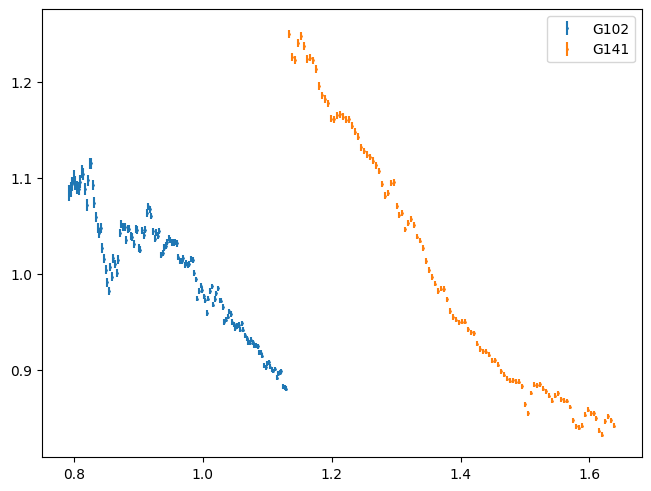

<Figure size 640x480 with 0 Axes>

In [3]:
###############################
# S22
###############################

visit = 'S22'
'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow
'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )
# out_of_transit.imshow()
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec
# Convert to JAX arrays
calibrated_mean_spec_G102 = jnp.array(calibrated_mean_spec)
oot_spec_err_G102 = jnp.array(oot_spec_err)
SED_wavelengths_G102 = jnp.array(_SED_wavelengths)

###############################
# F21
###############################
visit = 'F21'
'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow
'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
_oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = _oot_spec_err * calibrated_mean_spec
# Convert to JAX arrays
calibrated_mean_spec_G141 = jnp.array(calibrated_mean_spec)
oot_spec_err_G141 = jnp.array(oot_spec_err)
SED_wavelengths_G141 = jnp.array(_SED_wavelengths)

###############################
# PLOT DATA
###############################
plt.figure()
plt.errorbar(SED_wavelengths_G102,calibrated_mean_spec_G102,yerr=oot_spec_err_G102*100,fmt='o',label='G102',ms=1)
plt.errorbar(SED_wavelengths_G141,calibrated_mean_spec_G141,yerr=oot_spec_err_G141*100,fmt='o',label='G141',ms=1)
plt.legend()
plt.show()
plt.clf()

# Define Numpyro Model

In [4]:
def numpyro_model(N_temps=2, return_max_likelihood=False):
    """
    Define the probabilistic model in NUMPYRO with N_temps components.
    
    Args:
        N_temps: Number of temperature components (1, 2, 3, or 4)
        return_max_likelihood: If True, also return the maximum log likelihood value
    """
    def model():
        temp_bounds = [
            (3600, 4200),   # T1 bounds (higher temperature)
            (1000, 3600),   # T2 bounds (cooler component)
            (4500, 10000),  # T3 bounds 
        ]
        
        'Spectral Decomp Params'
        T_samples = []
        for i in range(1, N_temps + 1):
            if i == 1:
                T = numpyro.sample(f'T{i}', dist.TruncatedNormal(loc=4000, scale=50,
                                                              low=3700, high=4300))  
            if i == 2:
                # delta_T = numpyro.sample('delta_T',
                #                          dist.TruncatedNormal(loc=-750, scale=100,
                #                                               low=-1600, high=0))
                T = numpyro.sample(f'T{i}', dist.TruncatedNormal(loc=3000, scale=71,
                                                              low=2600, high=3600))      
                # T = numpyro.sample(f'T{i}', dist.Uniform(*temp_bounds[i-1]))
            if i ==3:
                T = numpyro.sample(f'T{i}', dist.Uniform(*temp_bounds[i-1]))
            T_samples.append(T)
        ff_samples = [1.0]  # First component always has f=1
        for i in range(2, N_temps + 1):
            ff = 10**numpyro.sample(f'ff{i}', dist.Uniform(-2, 1))
            ff_samples.append(ff)
        'Gridpoint Params'
        metallicity = 0.0#numpyro.sample('metallicity', dist.Uniform(-0.5, 0.5))
        # logg = 4.5 #numpyro.sample('logg', dist.Uniform(4.0, 5.0))
        sigma_conv = numpyro.sample('sigma_conv', dist.Uniform(0.3, 5.0))
        'Data Params'
        offset_G102 = numpyro.sample('offset_G102', dist.Uniform(0.0, 1.0))
        slope_G141 = numpyro.sample('slope_G141', dist.Uniform(-1.5, 0.5))
        slope_G102 = numpyro.sample('slope_G102', dist.Uniform(-1.5, 0.5))
        beta_102 = numpyro.sample('beta_G102', dist.Uniform(2.0, 2.5))
        beta_141 = numpyro.sample('beta_G141', dist.Uniform(2.0, 2.6))

        'Apply data params'
        offset_102 = jnp.asarray(offset_G102, dtype=jnp.float64)
        spec_G102_with_offset = jnp.array(calibrated_mean_spec_G102 + offset_102)
        spec_G102_with_slope = spec_G102_with_offset + slope_G102 * (SED_wavelengths_G102 - SED_wavelengths_G102[0])
        spec_G141_with_slope = jnp.array(calibrated_mean_spec_G141) + slope_G141 * (SED_wavelengths_G141 - SED_wavelengths_G141[0])
        _spec_flux_jax = jnp.concatenate([spec_G102_with_slope, spec_G141_with_slope])
        
        spec_flux_jax = _spec_flux_jax / jnp.mean(_spec_flux_jax)
        spec_err_jax = jnp.concatenate(
            [jnp.array((10**beta_102) * oot_spec_err_G102),
             jnp.array((10**beta_141) * oot_spec_err_G141)])
        combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), 
                                                    jnp.array(SED_wavelengths_G141)])
        
        @jit
        def decomp_model(temps, scales, metal_val, sigma):
            # Get spectra for all temperatures with variable metallicity AND logg
            spectra = [get_BTSettl_spectrum_jax(T=Temp, metallicity=metal_val) 
                        for Temp in temps]
            
            # Calculate combined spectrum with scaling factors
            flux_combined = scales[0] * spectra[0][1]  # Start with first component
            for i in range(1, N_temps):
                flux_combined += scales[i] * spectra[i][1]
            
            # Normalize
            _model_flux = flux_combined / jnp.mean(flux_combined)
            
            _binned_model_flux = shone.bin_spectrum(
                combined_SED_wavelengths, 
                panchromatic_wavelengths, 
                _model_flux
            )
            # Convolve and bin
            binned_model_flux = convolve_spectrum_jax(
                panchromatic_wavelengths, 
                _binned_model_flux, 
                sigma=jnp.asarray(sigma, dtype=jnp.float64)
            )

            model_flux = binned_model_flux / jnp.mean(binned_model_flux)
            
            return model_flux[2:-2]

        # Calculate model flux with both metallicity AND logg
        model_flux = decomp_model(T_samples, ff_samples, metallicity, sigma_conv)
        
        # Define the likelihood
        log_likelihood = dist.Normal(model_flux, spec_err_jax[2:-2]).log_prob(spec_flux_jax[2:-2]).sum()
        
        # # Add a prior on log likelihood to catch NaN values
        # log_likelihood = jnp.where(jnp.isnan(log_likelihood), -1e10, log_likelihood)
        
        # Sample the observed data
        numpyro.sample("Obs", dist.Normal(model_flux, spec_err_jax[2:-2]), obs=spec_flux_jax[2:-2])
        
        # Track log likelihood for maximum likelihood calculation
        if return_max_likelihood:
            numpyro.deterministic('log_likelihood', log_likelihood)
    
    if return_max_likelihood:
        def get_max_likelihood(samples):
            """Extract maximum log likelihood from samples"""
            log_lik_samples = samples.get('log_likelihood', None)
            if log_lik_samples is not None:
                return float(jnp.max(log_lik_samples))
            return None
        
        return model, get_max_likelihood
    else:
        return model

## Define Checkpoint Function

In [5]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')

    samples_cumulative = self.get_samples()
    corner.corner(samples_cumulative)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'../../figs/joint-visit_chkpt_{self.checkpoint}_sed_corner.png', dpi=200)
    plt.show()
    plt.clf()
    
    # EXTRACT MEDIAN PARAMETERS DIRECTLY FROM SAMPLES (like corner plot does)
    chkpt_median_params = {}
    for param_name, param_samples in samples_cumulative.items():
        # param_samples has shape (num_chains, num_samples)
        # Flatten across chains and compute median
        flattened_samples = param_samples.flatten()
        chkpt_median_params[param_name] = float(jnp.median(flattened_samples))
    
    print("Median parameters from samples:")
    for param, value in chkpt_median_params.items():
        print(f"  {param}: {value:.6f}")
    
    # Calculate and print maximum log likelihood
    if 'log_likelihood' in samples_cumulative:
        log_lik_samples = samples_cumulative['log_likelihood'].flatten()
        max_log_lik = float(jnp.max(log_lik_samples))
        print(f"Maximum log likelihood: {max_log_lik:.6f}")
        
        # Also compute Bayesian Information Criterion (BIC) if you want
        n_params = len([p for p in samples_cumulative.keys() if p != 'log_likelihood'])
        n_data = len(SED_wavelengths_G102) + len(SED_wavelengths_G141)  # number of data points
        bic = -2 * max_log_lik + n_params * jnp.log(n_data)
        print(f"BIC: {bic:.6f}")

    with open(f'../../data/samples/samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

## Define Plotting Function

In [6]:
def plot_sed_fit_results(mcmc, model_designation, n_temps):
    samples = mcmc.get_samples()
    result = arviz.from_numpyro(mcmc)
    
    'Get maximum likelihood index and parameters'
    # max_likelihood_idx = jnp.argmax(samples['log_likelihood'])
    # max_likelihood_params = {key: samples[key][max_likelihood_idx] for key in samples.keys()}

    log_likelihoods = samples['log_likelihood']
    # Find the index where log_likelihood is closest to the median
    median_log_likelihood = jnp.median(log_likelihoods)
    max_likelihood_idx = jnp.argmin(jnp.abs(log_likelihoods - median_log_likelihood))
    max_likelihood_params = {key: samples[key][max_likelihood_idx] for key in samples.keys()}
    
    'Random indices for posterior samples'
    n_total_samples = len(samples['log_likelihood'])
    random_indices = np.random.choice(n_total_samples, size=min(200, n_total_samples), replace=False)
    
    'Extract temperatures'
    temps = [jnp.asarray(samples[f'T{i}'][max_likelihood_idx], dtype=jnp.float64) for i in range(1, n_temps + 1)]
    print(f"\nTemperature components: {[f'{t:.0f}K' for t in temps]}")
    
    'Calculate filling factors for all samples'
    n_samples = n_total_samples
    all_filling_factors = np.zeros((n_samples, n_temps))
    for idx in range(n_samples):
        scales = [1.0] + [10**samples[f'ff{i}'][idx] for i in range(2, n_temps + 1)]
        total_scale = sum(scales)
        all_filling_factors[idx, :] = [scale / total_scale for scale in scales]
    'FF Statistics'
    ff_medians = np.median(all_filling_factors, axis=0)
    ff_percentiles = np.percentile(all_filling_factors, [16, 84], axis=0)
    ff_means = np.mean(all_filling_factors, axis=0)
    ff_stds = np.std(all_filling_factors, axis=0)
    print("\n" + "="*60)
    print("FILLING FACTORS FOR EACH COMPONENT (from full posterior)")
    print("="*60)
    for i in range(n_temps):
        print(f"Component {i+1} (T = {temps[i]:.0f}K):")
        print(f"  Median = {ff_medians[i]:.4f} ({ff_medians[i]*100:.2f}%)")
        print(f"  Mean ± Std = {ff_means[i]:.4f} ± {ff_stds[i]:.4f}")
        print(f"  16th-84th percentile = [{ff_percentiles[0,i]:.4f}, {ff_percentiles[1,i]:.4f}]")
        print(f"  Range = [{np.min(all_filling_factors[:,i]):.4f}, {np.max(all_filling_factors[:,i]):.4f}]")
    print(f"\nSum of median filling factors: {np.sum(ff_medians):.4f}")
    print("="*60 + "\n")
    
    #-------------------------------------------------------
    # Filling Factor plot
    fig_ff, axes_ff = plt.subplots(1, n_temps, figsize=(4*n_temps, 4))
    if n_temps == 1:
        axes_ff = [axes_ff]
    for i in range(n_temps):
        axes_ff[i].hist(all_filling_factors[:, i], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes_ff[i].axvline(ff_medians[i], color='red', linestyle='--', label=f'Median: {ff_medians[i]:.3f}')
        axes_ff[i].axvline(ff_percentiles[0, i], color='orange', linestyle=':', label='16th/84th')
        axes_ff[i].axvline(ff_percentiles[1, i], color='orange', linestyle=':')
        axes_ff[i].set_xlabel(f'Filling Factor - Comp {i+1}')
        axes_ff[i].set_ylabel('Frequency')
        axes_ff[i].legend(fontsize=8)
        axes_ff[i].set_title(f'T{temps[i]:.0f}K')
    plt.suptitle('Filling Factor Distributions')
    plt.tight_layout()
    plt.savefig(f'../../figs/{model_designation}_filling_factor_distributions.png', dpi=200)
    #-------------------------------------------------------
    
    'Prepare data'
    spec_G102 = jnp.array(calibrated_mean_spec_G102 + jnp.asarray(max_likelihood_params['offset_G102'], dtype=jnp.float64))
    spec_G141 = jnp.array(calibrated_mean_spec_G141)
    _spec_flux_jax = jnp.concatenate([
        spec_G102 + max_likelihood_params['slope_G102'] * (SED_wavelengths_G102 - SED_wavelengths_G102[0]),
        spec_G141 + max_likelihood_params['slope_G141'] * (SED_wavelengths_G141 - SED_wavelengths_G141[0])
    ])
    max_likelihood_spec_flux = _spec_flux_jax / jnp.mean(_spec_flux_jax)
    max_likelihood_spec_err = jnp.concatenate([
        jnp.array(oot_spec_err_G102 * jnp.asarray(10**max_likelihood_params['beta_G102'], dtype=jnp.float64)),
        jnp.array(oot_spec_err_G141 * jnp.asarray(10**max_likelihood_params['beta_G141'], dtype=jnp.float64))
    ])
    combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), jnp.array(SED_wavelengths_G141)])
        
    'Get spectra and scales for max likelihood'
    spectra = [get_BTSettl_spectrum_jax(T=Temp, metallicity=0) for Temp in temps]
    scales = [1.0] + [jnp.asarray(10**max_likelihood_params[f'ff{i}'], dtype=jnp.float64) for i in range(2, n_temps + 1)]
    
    'Max likelihood filling factors'
    total_scale = sum(scales)
    ml_filling_factors = [scale / total_scale for scale in scales]
    print("\nMaximum Likelihood Filling Factors:")
    for i, ff in enumerate(ml_filling_factors, 1):
        print(f"  Component {i}: {ff:.4f} ({ff*100:.2f}%)")
    
    'Calculate combined flux from components'
    _max_likelihood_flux = sum(scales[i] * spectra[i][1] for i in range(n_temps))
    component_fluxes = []
    for i in range(n_temps):
        comp_flux = scales[i] * spectra[i][1]
        comp_flux_norm = comp_flux / jnp.mean(_max_likelihood_flux)
        comp_binned = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, comp_flux_norm)
        comp_convolved = convolve_spectrum_jax(panchromatic_wavelengths, comp_binned, sigma=max_likelihood_params['sigma_conv'])
        component_fluxes.append(comp_convolved / jnp.mean(comp_convolved))
    
    'Max Likelihood Combined spectrum'
    _model_flux = _max_likelihood_flux / jnp.mean(_max_likelihood_flux)
    binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, _model_flux)
    convolved = convolve_spectrum_jax(panchromatic_wavelengths, binned_model_flux, sigma=max_likelihood_params['sigma_conv'])
    max_likelihood_model_flux = convolved / jnp.mean(convolved)

    'Compute model flux'
    def compute_model_flux(params):
        temps = [jnp.asarray(params[f'T{i}'], dtype=jnp.float64) for i in range(1, n_temps + 1)]
        spectra = [get_BTSettl_spectrum_jax(T=Temp, metallicity=0) for Temp in temps]
        
        scales = [1.0] + [jnp.asarray(10**params[f'ff{i}'], dtype=jnp.float64) for i in range(2, n_temps + 1)]
        
        _flux = scales[0] * spectra[0][1]
        for i in range(1, n_temps):
            _flux += scales[i] * spectra[i][1]
        
        _model_flux = _flux / jnp.mean(_flux)
        _binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, _model_flux)
        binned_model_flux = convolve_spectrum_jax(panchromatic_wavelengths, _binned_model_flux, sigma=params[f'sigma_conv'])
        
        return binned_model_flux / jnp.mean(binned_model_flux)
    
    #-------------------------------------------------------
    # Model + Data Plot
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'0.8-1.64 μm SED with {n_temps}T Model (Maximum Likelihood)', fontsize=20)
    axs[1].set_title('Residuals', fontsize=14)
    axs[1].set_xlim(0.805, 1.645)
    axs[1].set_ylim(-4, 4)
    axs[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=14)
    axs[0].set_ylabel('Relative Flux', fontsize=14)
    axs[1].set_ylabel(r'$\sigma$', fontsize=14)
    'Plot random posterior samples'
    for idx in random_indices:
        random_params = {key: samples[key][idx] for key in samples.keys()}
        random_model_flux = compute_model_flux(random_params)
        axs[0].plot(combined_SED_wavelengths[:-3], random_model_flux[:-3], color='red', alpha=0.05, linewidth=0.5, zorder=50)
    'Plot individual components'
    colors = ['green', 'purple', 'cyan', 'orange'][:n_temps]
    for i in range(n_temps):
        label = f'T{temps[i]:.0f}K: ff = {ff_medians[i]:.3f} ± {ff_stds[i]:.3f}'
        axs[0].plot(combined_SED_wavelengths[:-1], ff_medians[i] * component_fluxes[i][:-1],
                    color=colors[i], linewidth=2, linestyle='--', label=label, zorder=100, alpha=0.5)
    'Plot Data'
    axs[0].errorbar(combined_SED_wavelengths, max_likelihood_spec_flux, yerr=max_likelihood_spec_err,
                    fmt='o', color='b', ms=1, alpha=0.7, zorder=150, label='Data')
    'Plot Max Likelihood Model'
    axs[0].plot(combined_SED_wavelengths[:-2], max_likelihood_model_flux[:-2], color='k', linewidth=2, zorder=200, label='Model')
    axs[0].legend(loc='upper right', fontsize=10)
    'Plot Residuals'
    axs[1].scatter(combined_SED_wavelengths, (max_likelihood_model_flux - max_likelihood_spec_flux) / max_likelihood_spec_err,
                   color='gray', zorder=150)
    axs[1].axhline(0, color='k', zorder=-100)
    plt.tight_layout()
    plt.savefig(f'../../figs/{model_designation}_max_likelihood_result.png', dpi=200)
    #-------------------------------------------------------

    #-------------------------------------------------------
    # Corner plot
    corner.corner(result)
    plt.savefig(f'../../figs/{model_designation}_corner.png', dpi=200)
    #-------------------------------------------------------

## Run 1T Model

In [7]:
# bt_lib = 'agss-logg4.5-met0.0' # GNS93, generic, CIFIST, AGSS2009
# n_temps = 1
# n_warmup = 5_00
# n_samples = 1_000
# n_chains = 8
# n_check = 2

# # Get the model function and callback
# model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

# model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_btsettl_{bt_lib}'

# rng_key = PRNGKey(42)

# sampler = NUTS(
#     model_func,  # Use the returned function
#     dense_mass=False
# )

# mcmc = MCMCWithCheckpoints(
#     sampler, 
#     num_warmup=n_warmup, 
#     num_samples=n_samples,
#     num_chains=n_chains
# )

# mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

# mcmc.print_summary()

# result = arviz.from_numpyro(mcmc)

# 'Save the result'
# result.to_netcdf(f'../../data/samples/{model_designation}')

# # Extract maximum likelihood after sampling
# if get_max_likelihood is not None:
#     samples = mcmc.get_samples()
#     max_log_lik = get_max_likelihood(samples)
#     print(f"Maximum log likelihood: {max_log_lik:.6f}")

# 'Print the summary'
# arviz.summary(result)

In [8]:
# 'Examine the Leave-One-Out (LOO) summary'
# loo = arviz.loo(result, pointwise=True)
# loo

In [9]:
# plot_sed_fit_results(mcmc, model_designation, n_temps)

## Run 2T Model

  0%|          | 0/3 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Corner for checkpoint 0


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


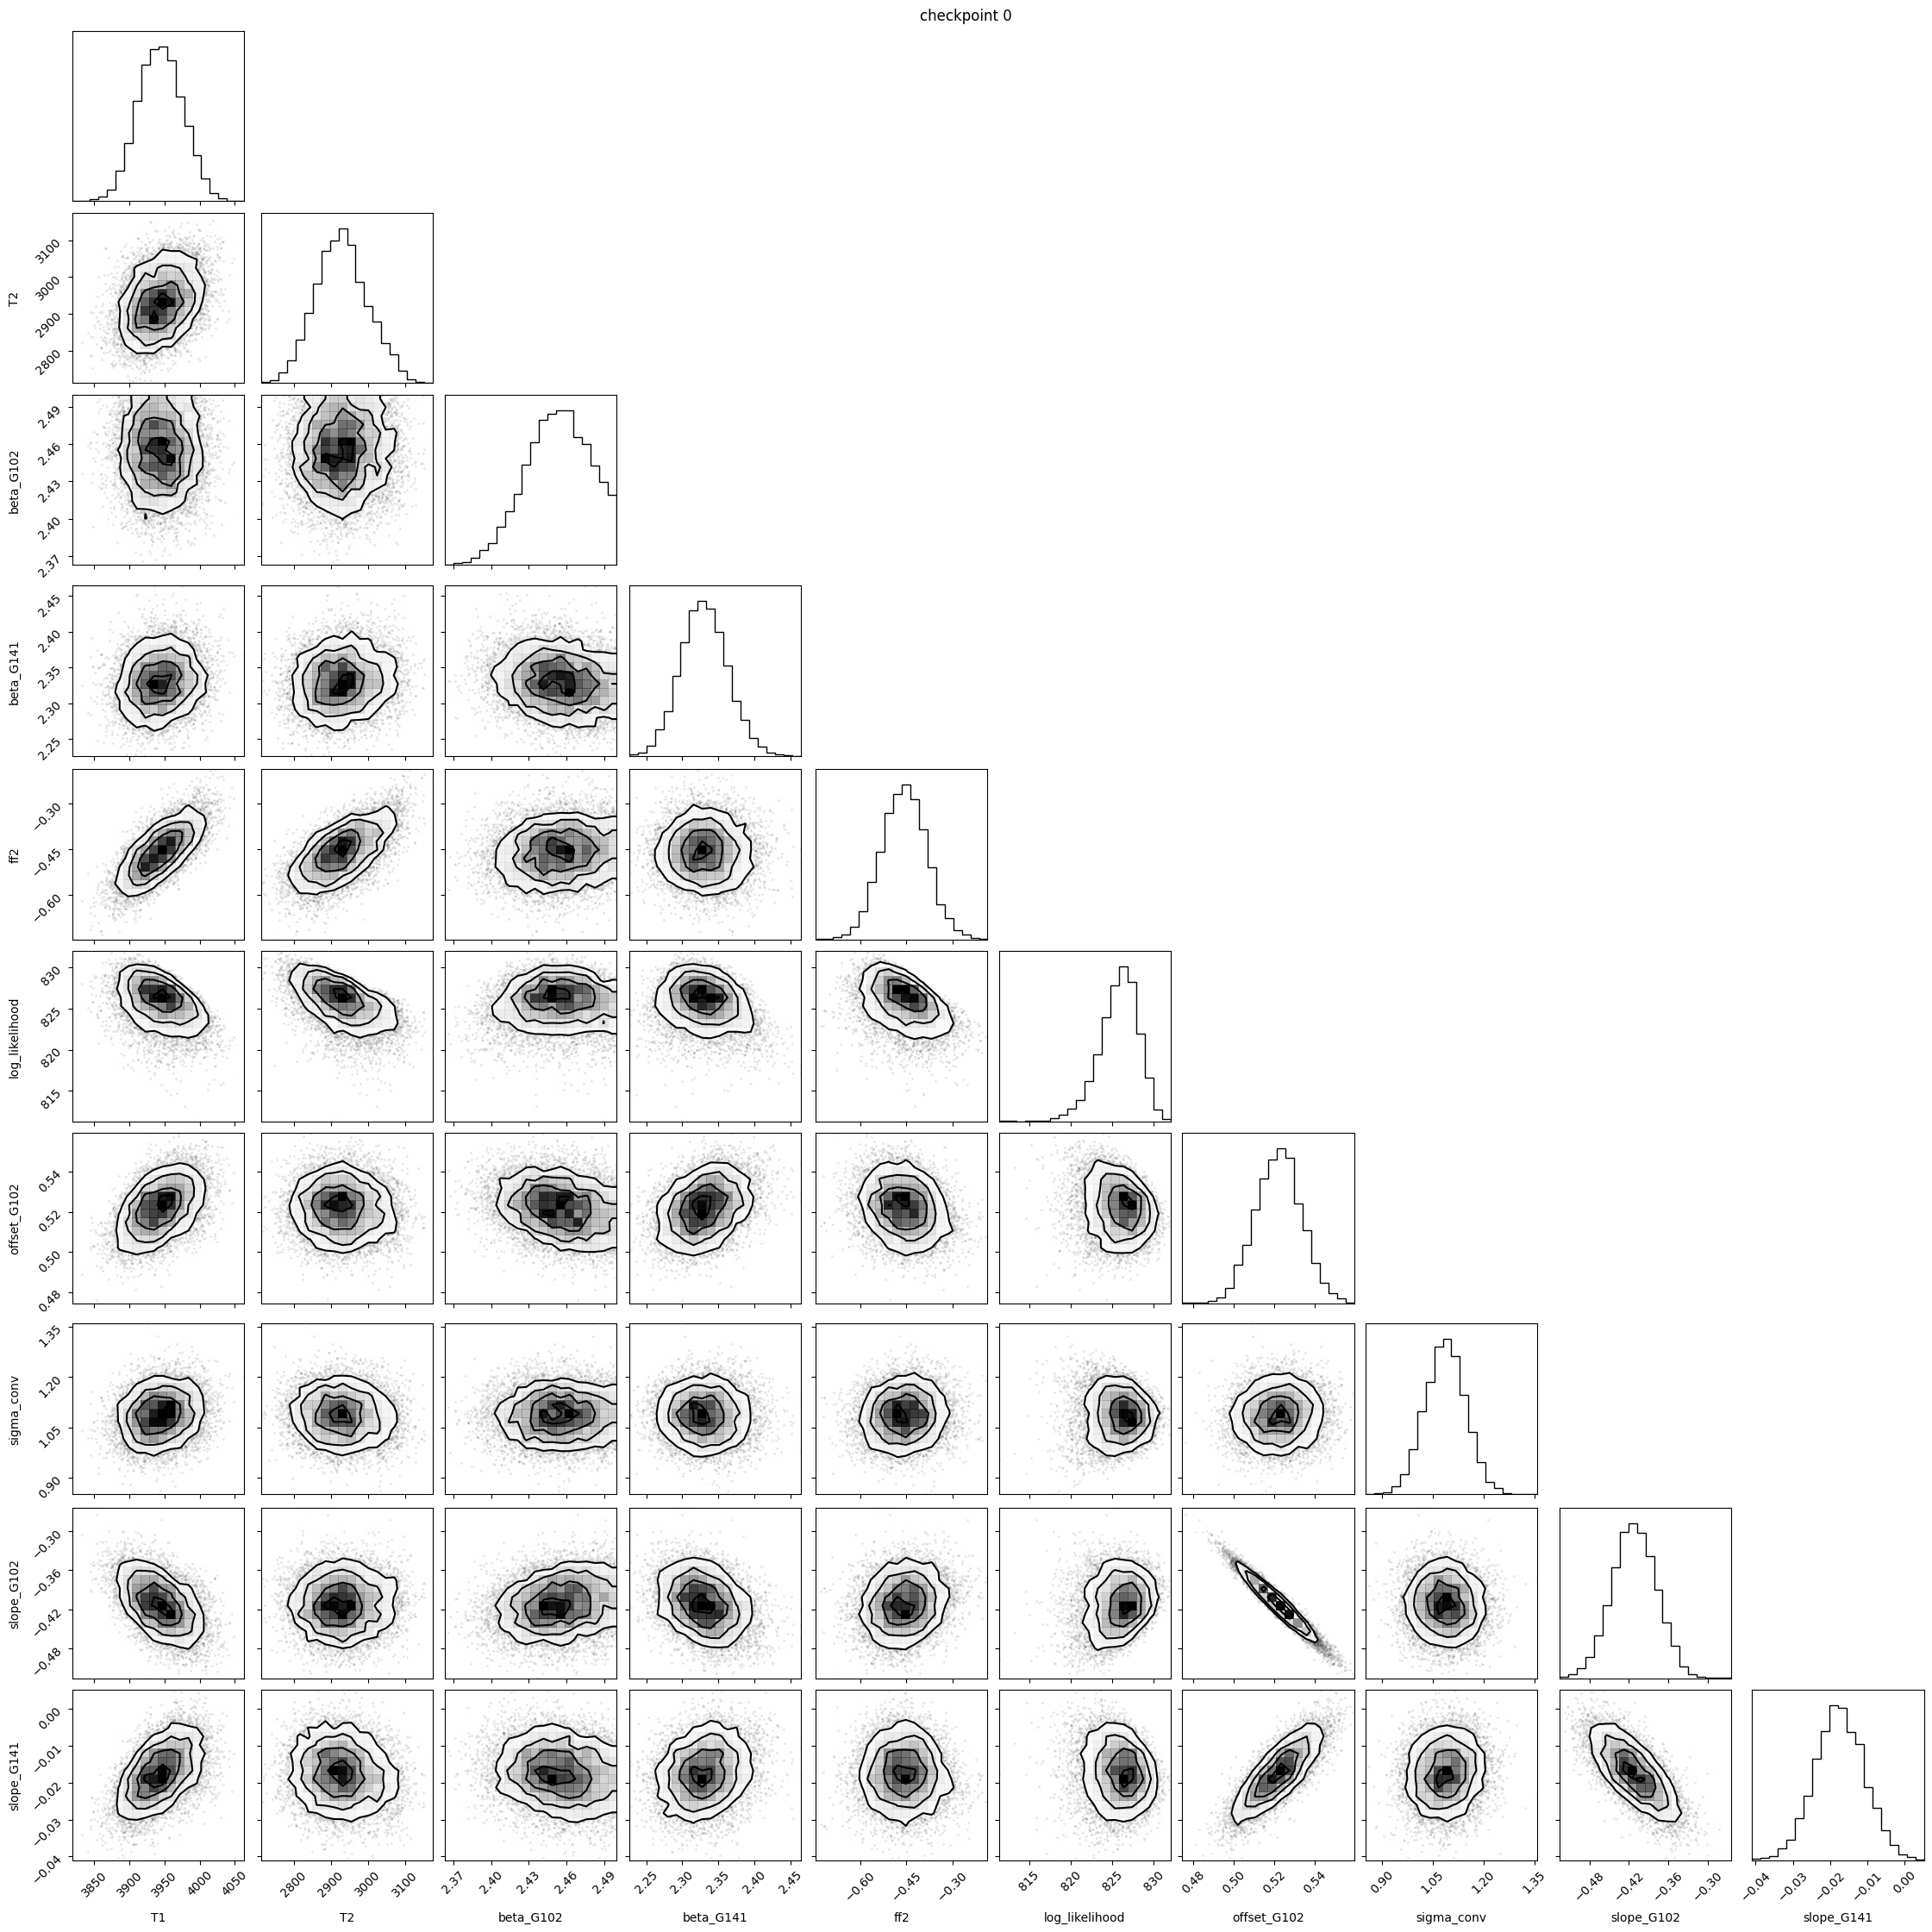

Median parameters from samples:
  T1: 3943.411144
  T2: 2927.735786
  beta_G102: 2.453739
  beta_G141: 2.329747
  ff2: -0.457669
  log_likelihood: 825.973098
  offset_G102: 0.522022
  sigma_conv: 1.086916
  slope_G102: -0.412077
  slope_G141: -0.017512
Maximum log likelihood: 832.053074
BIC: -1614.485290


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Corner for checkpoint 1


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


<Figure size 640x480 with 0 Axes>

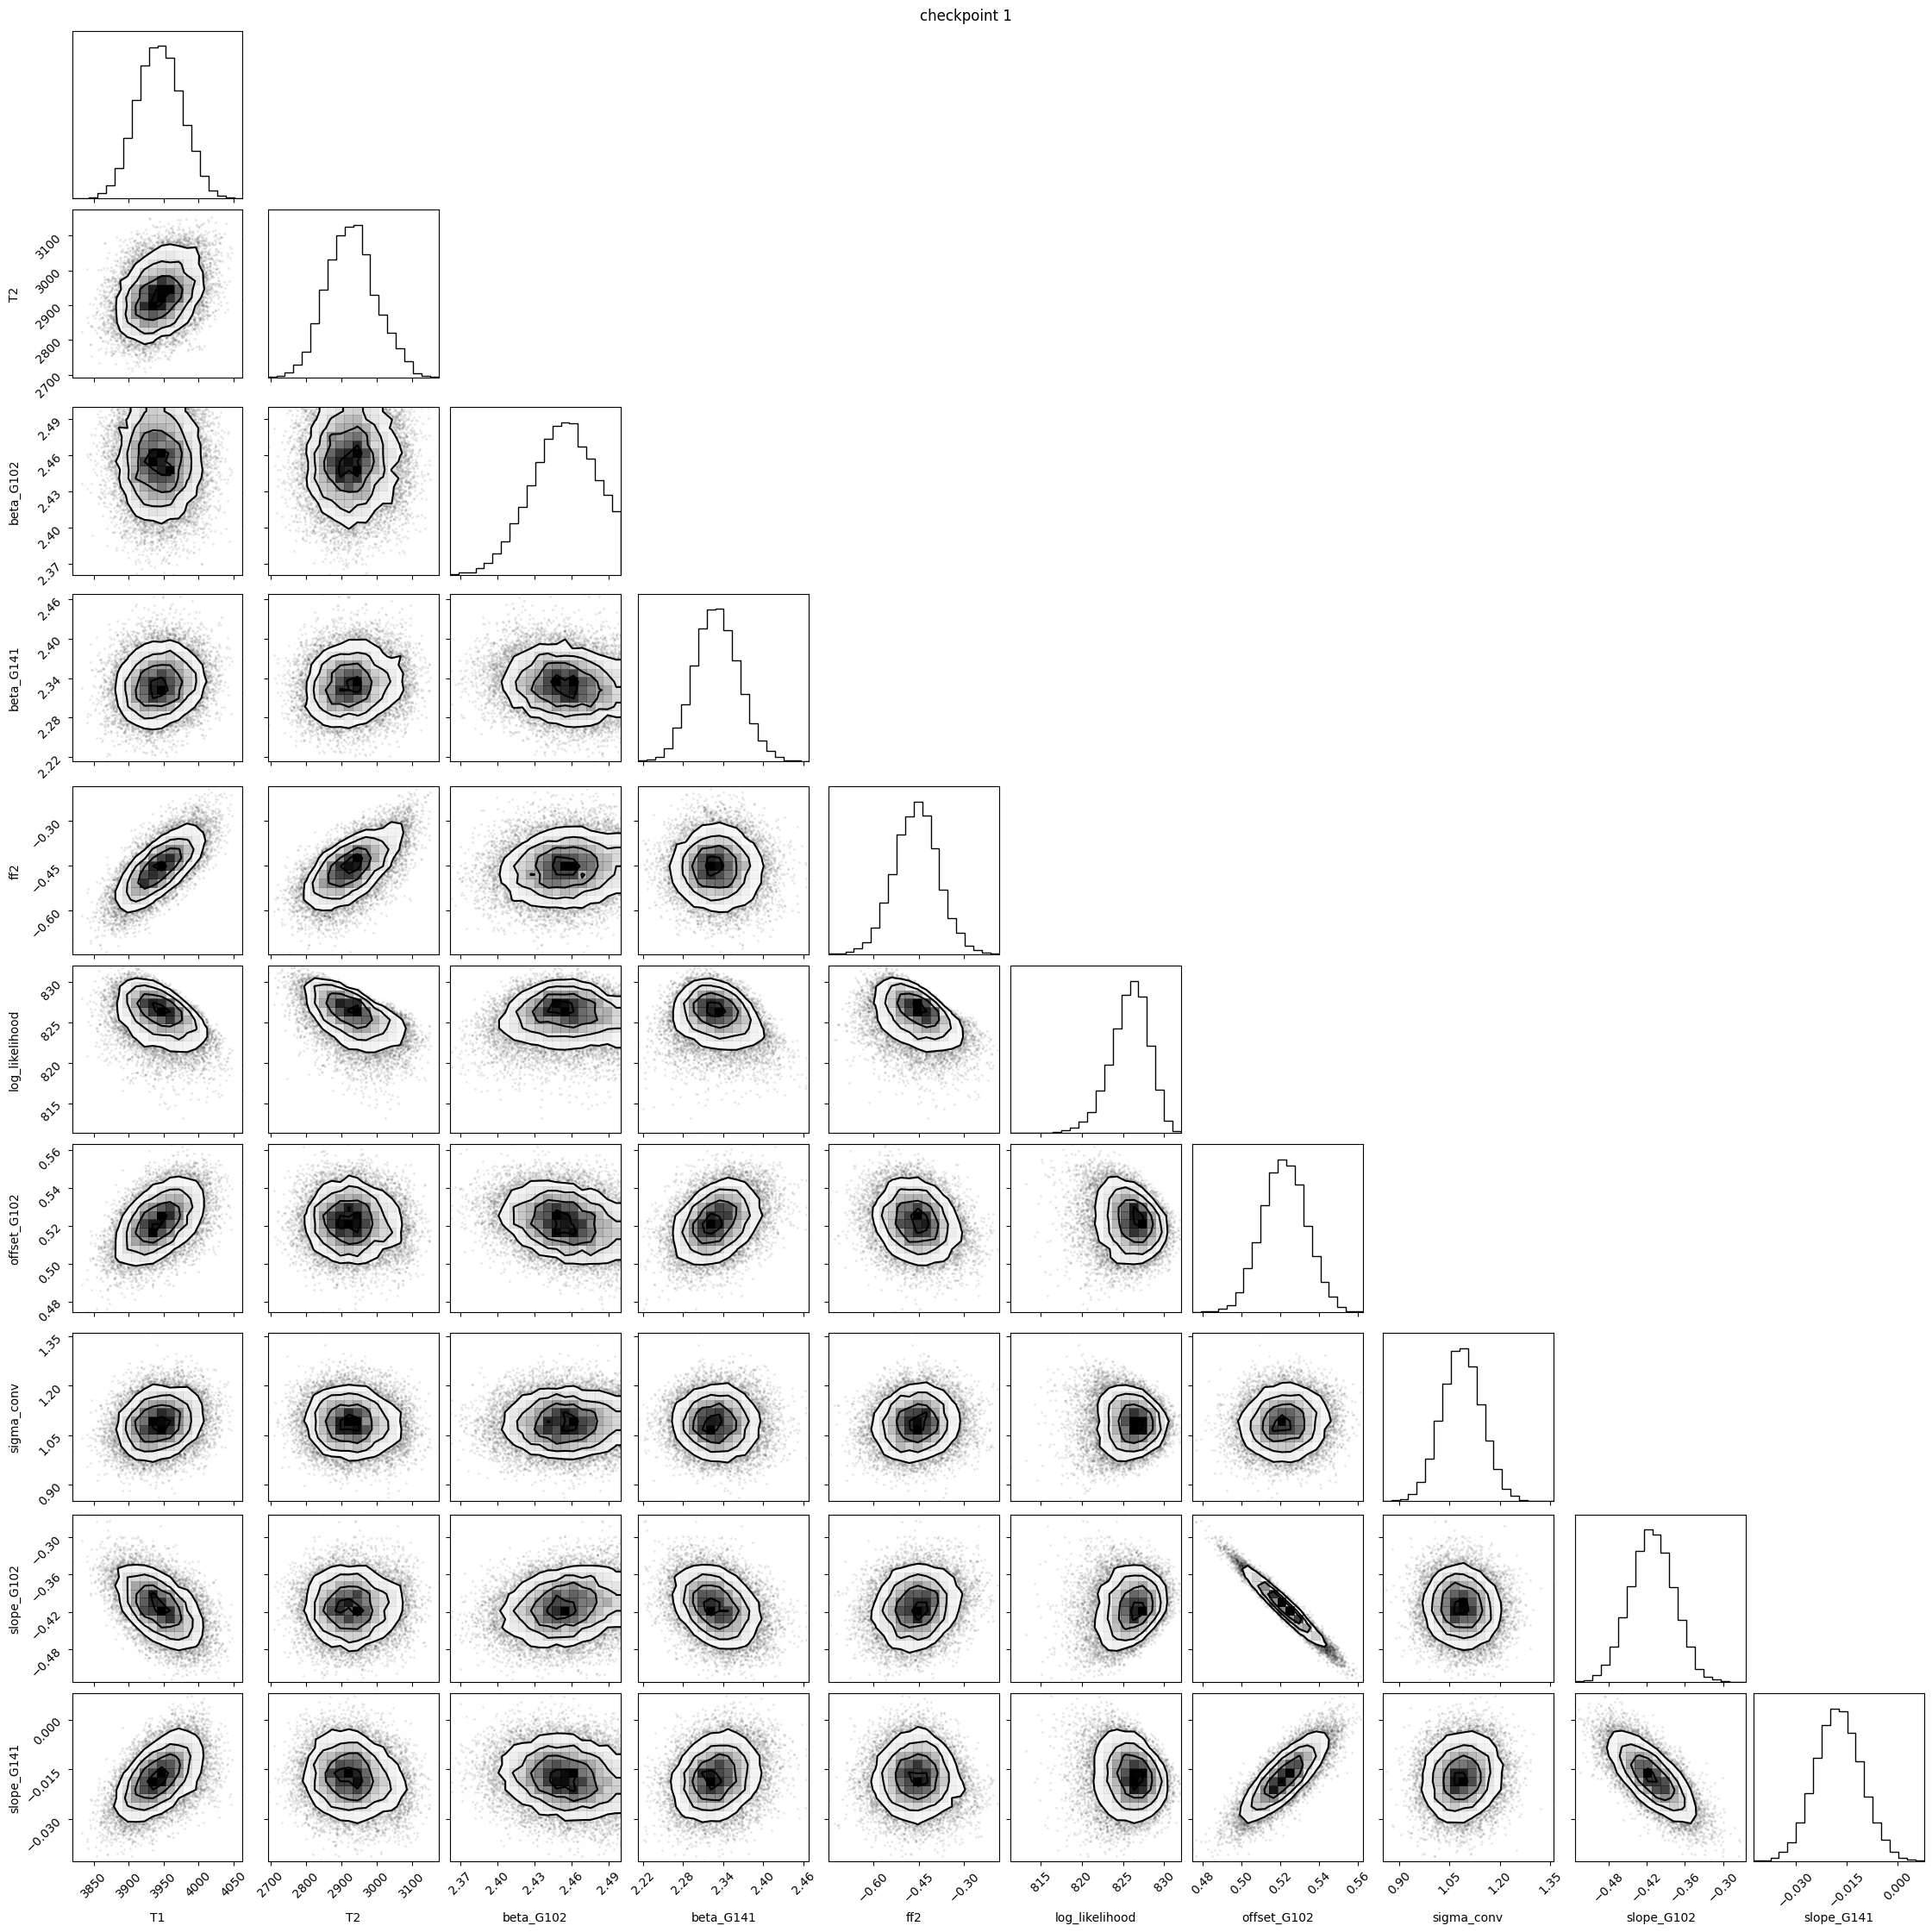

Median parameters from samples:
  T1: 3943.734446
  T2: 2927.743670
  beta_G102: 2.453827
  beta_G141: 2.329717
  ff2: -0.457664
  log_likelihood: 825.944232
  offset_G102: 0.521989
  sigma_conv: 1.086095
  slope_G102: -0.411942
  slope_G141: -0.017450
Maximum log likelihood: 832.053074
BIC: -1614.485290

                   mean       std    median      5.0%     95.0%     n_eff     r_hat
           T1   3943.99     31.65   3943.73   3893.66   3997.72   5732.11      1.00
           T2   2929.49     69.28   2927.74   2813.36   3043.88   8260.99      1.00
    beta_G102      2.45      0.03      2.45      2.41      2.50   8667.37      1.00
    beta_G141      2.33      0.03      2.33      2.28      2.38  10447.98      1.00
          ff2     -0.46      0.07     -0.46     -0.58     -0.34   6447.37      1.00
  offset_G102      0.52      0.01      0.52      0.50      0.54   5675.80      1.00
   sigma_conv      1.09      0.06      1.09      0.99      1.18  12033.52      1.00
   slope_G102     -0.

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
T1,3943.986,31.650,3886.342,4003.508,0.417,0.244,5754.0,7725.0,1.0
T2,2929.488,69.285,2807.536,3069.573,0.761,0.540,8307.0,9013.0,1.0
beta_G102,2.453,0.025,2.411,2.500,0.000,0.000,7249.0,4384.0,1.0
beta_G141,2.331,0.033,2.267,2.392,0.000,0.000,10494.0,10202.0,1.0
ff2,-0.458,0.073,-0.595,-0.319,0.001,0.001,6501.0,7598.0,1.0
log_likelihood,825.748,2.343,821.381,829.975,0.029,0.020,6674.0,9724.0,1.0
offset_G102,0.522,0.011,0.501,0.544,0.000,0.000,5696.0,7776.0,1.0
sigma_conv,1.087,0.058,0.975,1.193,0.001,0.000,12090.0,9304.0,1.0
slope_G102,-0.412,0.034,-0.475,-0.347,0.000,0.000,5957.0,8203.0,1.0
slope_G141,-0.017,0.007,-0.030,-0.004,0.000,0.000,6400.0,8984.0,1.0


<Figure size 640x480 with 0 Axes>

In [10]:
bt_lib = 'agss-logg4.5-met0.0' # GNS93, generic, CIFIST, AGSS2009
n_temps = 2
n_warmup = 5_00
n_samples = 2_000
n_chains = 8
n_check = 2

# Get the model function and callback
model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_btsettl_{bt_lib}'

rng_key = PRNGKey(42)

sampler = NUTS(
    model_func,  # Use the returned function
    dense_mass=False
)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()

result = arviz.from_numpyro(mcmc)

'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

# Extract maximum likelihood after sampling
if get_max_likelihood is not None:
    samples = mcmc.get_samples()
    max_log_lik = get_max_likelihood(samples)
    print(f"Maximum log likelihood: {max_log_lik:.6f}")

'Print the summary'
arviz.summary(result)

In [11]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

Computed from 16000 posterior samples and 244 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   821.61    11.45
p_loo        7.74        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      244  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Temperature components: ['3946K', '2920K']

FILLING FACTORS FOR EACH COMPONENT (from full posterior)
Component 1 (T = 3946K):
  Median = 0.7415 (74.15%)
  Mean ± Std = 0.7405 ± 0.0320
  16th-84th percentile = [0.7097, 0.7718]
  Range = [0.6052, 0.8483]
Component 2 (T = 2920K):
  Median = 0.2585 (25.85%)
  Mean ± Std = 0.2595 ± 0.0320
  16th-84th percentile = [0.2282, 0.2903]
  Range = [0.1517, 0.3948]

Sum of median filling factors: 1.0000



/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_36769/1754643903.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



Maximum Likelihood Filling Factors:
  Component 1: 0.7608 (76.08%)
  Component 2: 0.2392 (23.92%)


/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_36769/1754643903.py:155: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


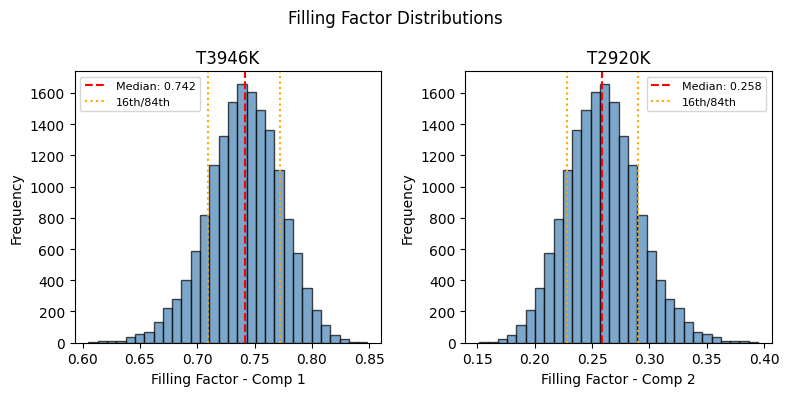

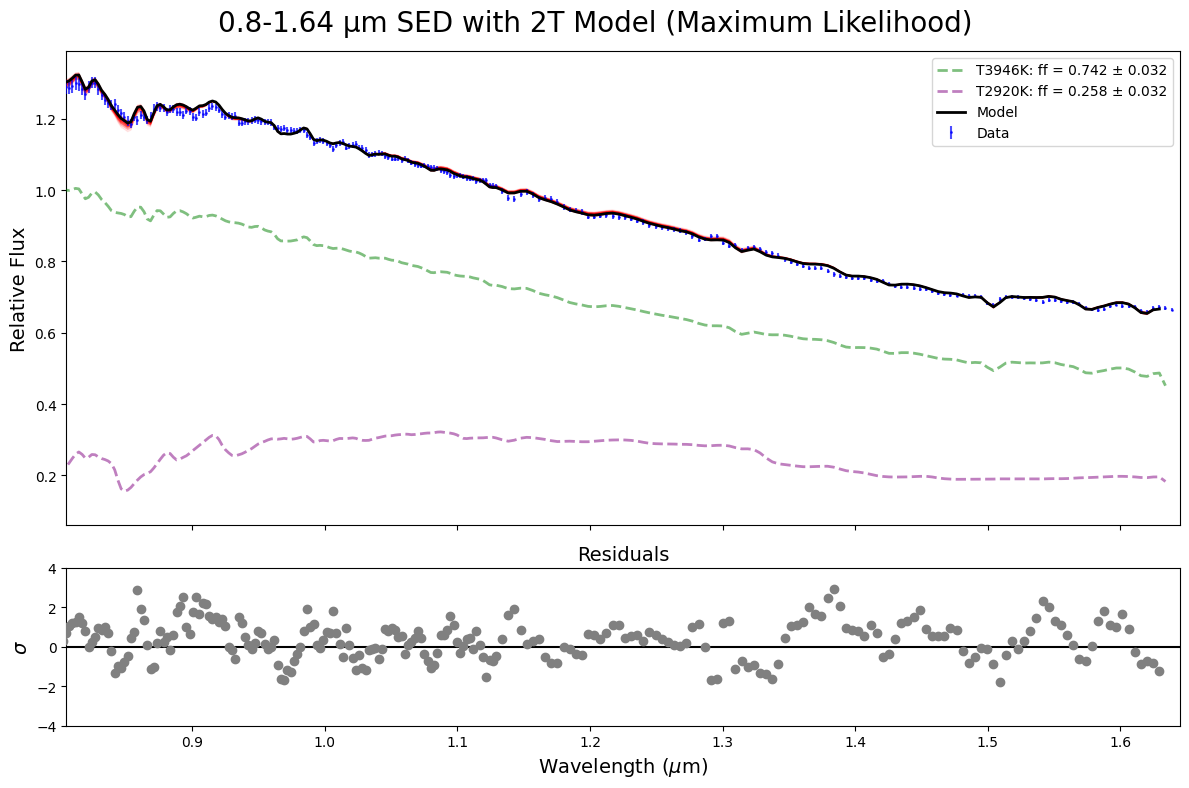

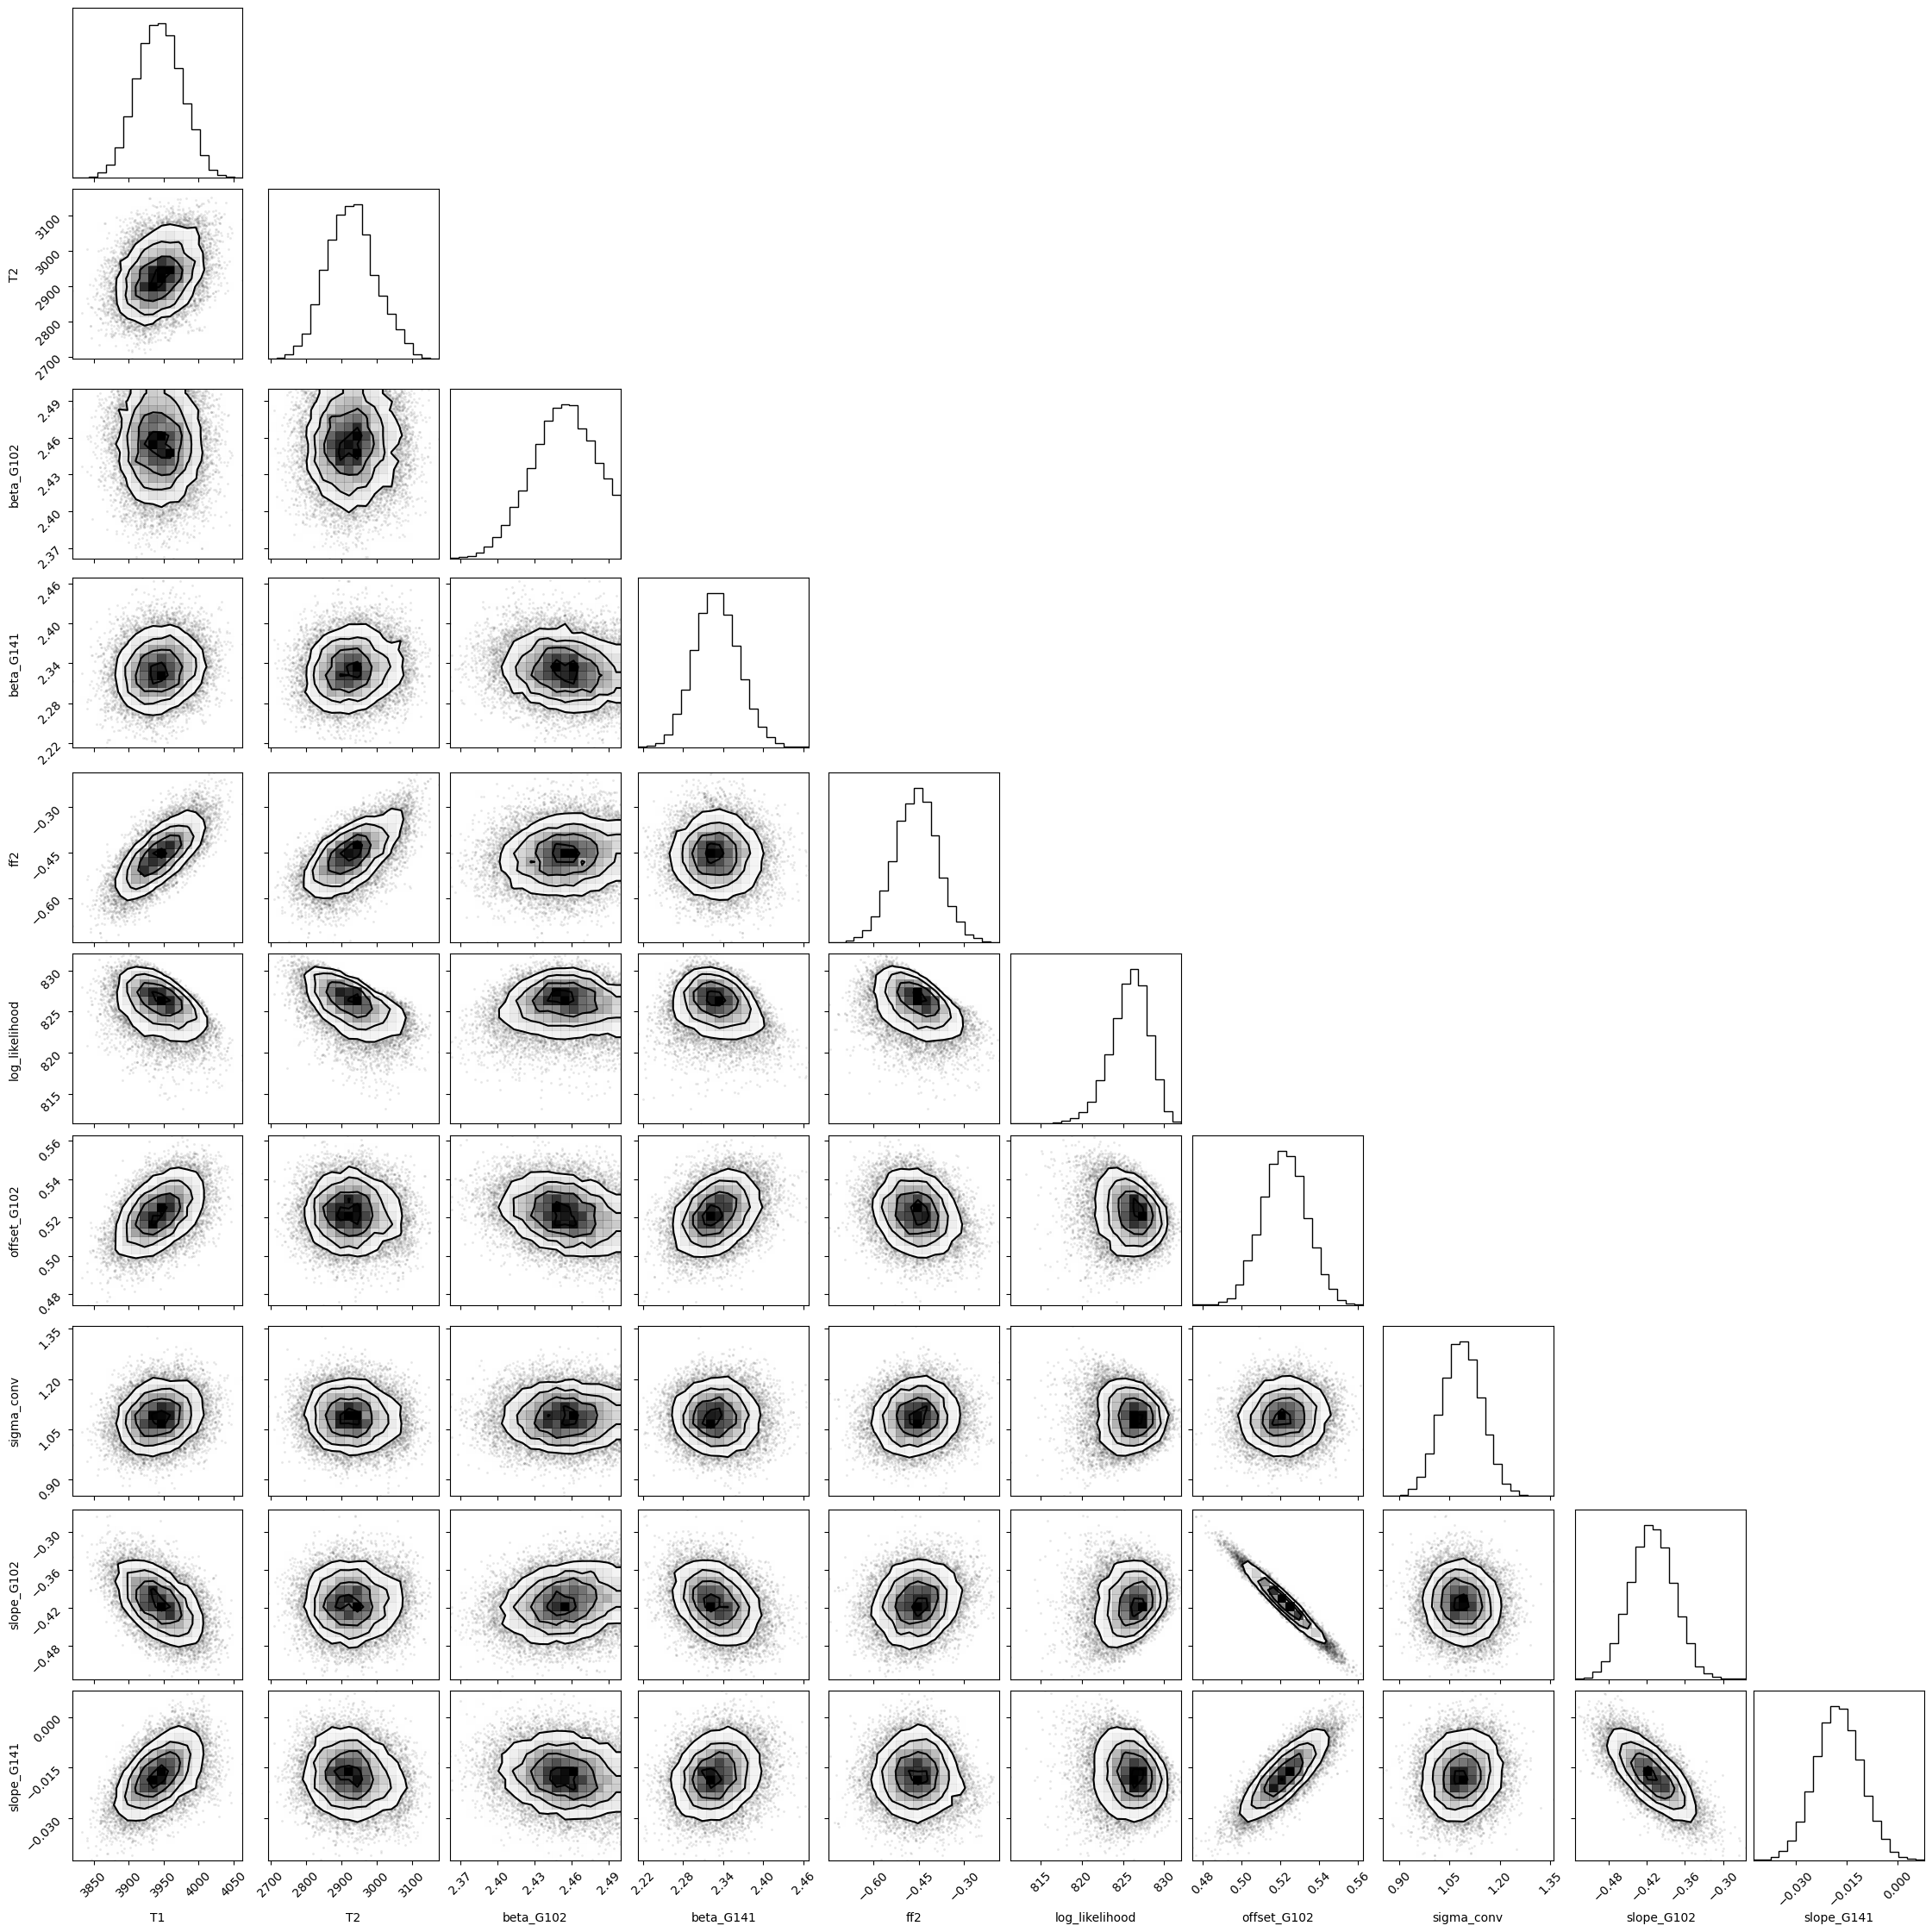

In [12]:
plot_sed_fit_results(mcmc, model_designation, n_temps)

## Run 3T Model

  0%|          | 0/3 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Corner for checkpoint 0


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


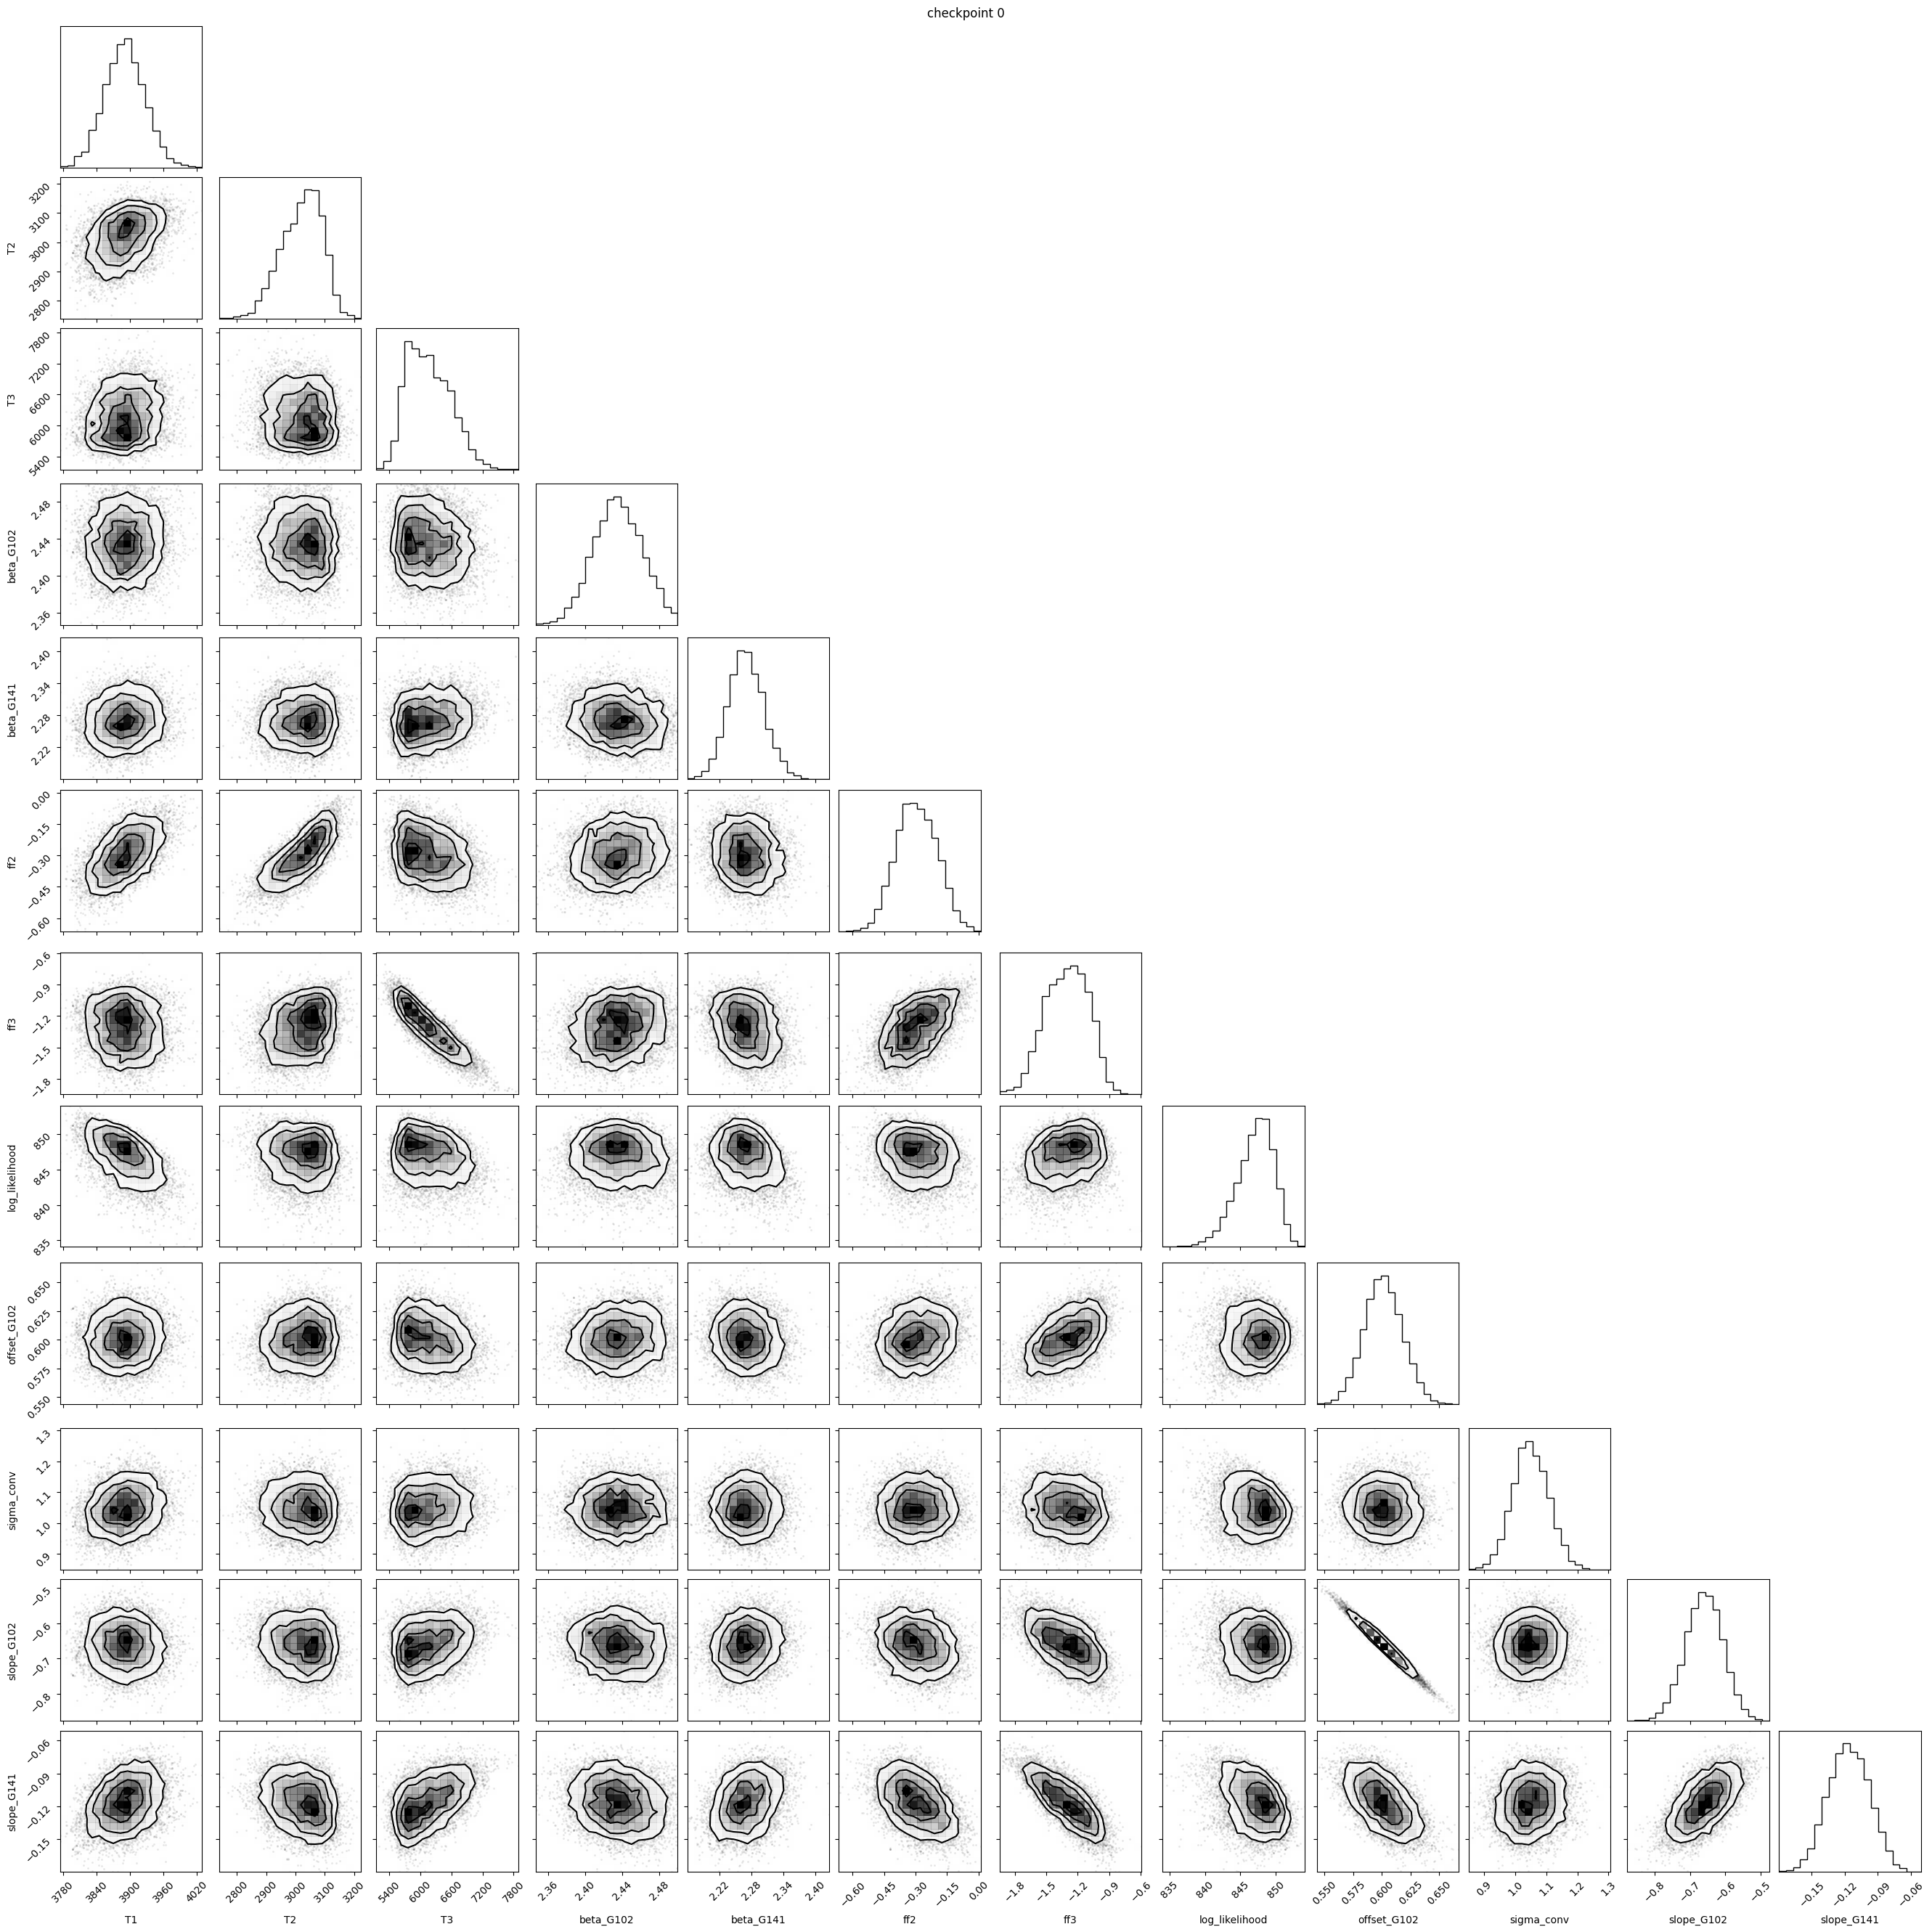

Median parameters from samples:
  T1: 3890.215055
  T2: 3028.320543
  T3: 6117.893403
  beta_G102: 2.434674
  beta_G141: 2.269447
  ff2: -0.297198
  ff3: -1.298331
  log_likelihood: 847.348103
  offset_G102: 0.600881
  sigma_conv: 1.047710
  slope_G102: -0.659175
  slope_G141: -0.116472
Maximum log likelihood: 854.100145
BIC: -1647.552574


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Corner for checkpoint 1


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


<Figure size 640x480 with 0 Axes>

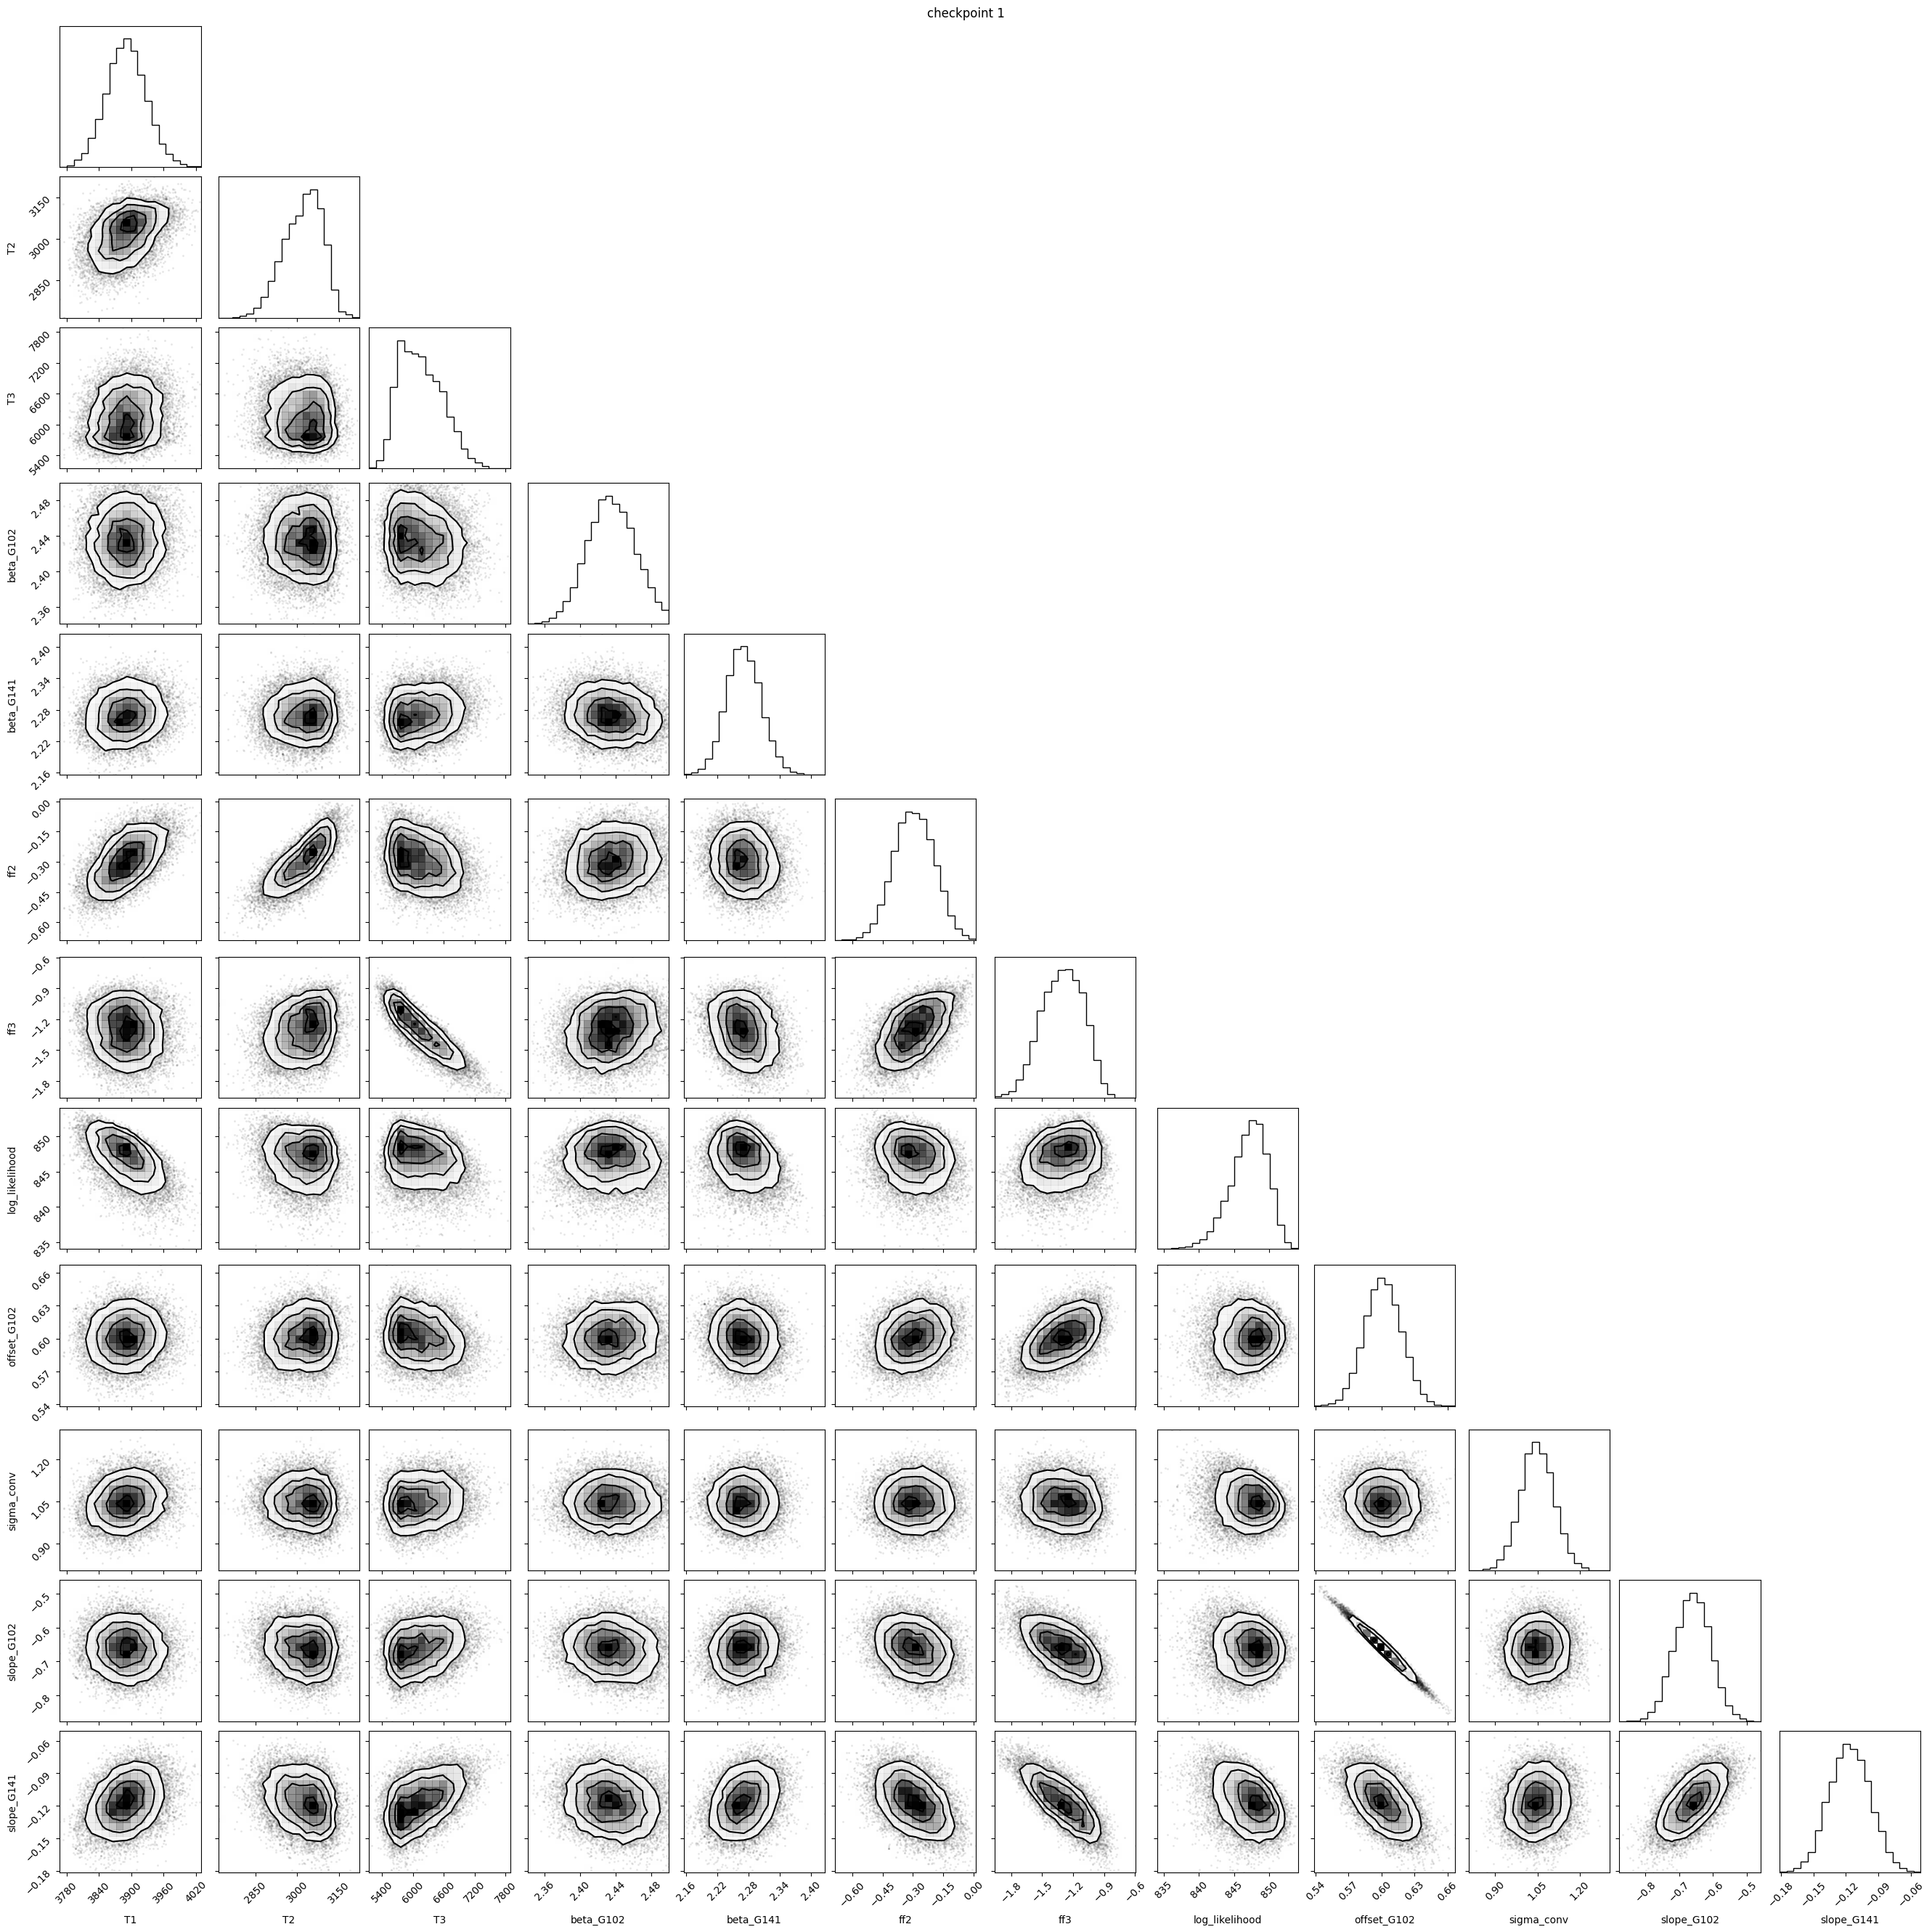

Median parameters from samples:
  T1: 3890.407310
  T2: 3027.738788
  T3: 6116.683900
  beta_G102: 2.434768
  beta_G141: 2.269535
  ff2: -0.295428
  ff3: -1.300135
  log_likelihood: 847.307267
  offset_G102: 0.601175
  sigma_conv: 1.048783
  slope_G102: -0.660161
  slope_G141: -0.116479
Maximum log likelihood: 854.100145
BIC: -1647.552574

                   mean       std    median      5.0%     95.0%     n_eff     r_hat
           T1   3890.74     36.75   3890.41   3827.19   3948.45   7622.47      1.00
           T2   3019.98     68.74   3027.74   2907.40   3125.18   6458.78      1.00
           T3   6162.97    411.64   6116.68   5541.50   6820.40   5310.35      1.00
    beta_G102      2.44      0.03      2.43      2.39      2.48   8086.26      1.00
    beta_G141      2.27      0.03      2.27      2.22      2.32   9388.57      1.00
          ff2     -0.29      0.10     -0.30     -0.45     -0.13   4928.64      1.00
          ff3     -1.31      0.20     -1.30     -1.63     -0.99   3810

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
T1,3890.741,36.752,3818.053,3957.321,0.421,0.314,7574.0,7586.0,1.0
T2,3019.984,68.738,2887.877,3134.946,0.856,0.542,6660.0,8192.0,1.0
T3,6162.965,411.640,5515.918,6956.460,5.631,3.155,5700.0,8367.0,1.0
beta_G102,2.435,0.027,2.386,2.486,0.000,0.000,7743.0,3981.0,1.0
beta_G141,2.270,0.033,2.211,2.337,0.000,0.000,9364.0,8192.0,1.0
ff2,-0.295,0.098,-0.480,-0.117,0.001,0.001,4965.0,8482.0,1.0
ff3,-1.306,0.199,-1.666,-0.952,0.003,0.002,3899.0,5895.0,1.0
log_likelihood,847.006,2.678,841.945,851.684,0.034,0.023,6048.0,8763.0,1.0
offset_G102,0.601,0.017,0.571,0.634,0.000,0.000,5313.0,7345.0,1.0
sigma_conv,1.050,0.059,0.944,1.165,0.001,0.000,11176.0,9150.0,1.0


<Figure size 640x480 with 0 Axes>

In [13]:
bt_lib = 'agss-logg4.5-met0.0' # GNS93, generic, CIFIST, AGSS2009
n_temps = 3
n_warmup = 5_00
n_samples = 2_000
n_chains = 8
n_check = 2

# Get the model function and callback
model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_btsettl_{bt_lib}'

rng_key = PRNGKey(42)

sampler = NUTS(
    model_func,  # Use the returned function
    dense_mass=False
)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()

# Extract maximum likelihood after sampling
if get_max_likelihood is not None:
    samples = mcmc.get_samples()
    max_log_lik = get_max_likelihood(samples)
    print(f"Maximum log likelihood: {max_log_lik:.6f}")

result = arviz.from_numpyro(mcmc)

'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

In [14]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

Computed from 16000 posterior samples and 244 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   841.99    12.53
p_loo        9.47        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      244  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Temperature components: ['3942K', '3124K', '5664K']

FILLING FACTORS FOR EACH COMPONENT (from full posterior)
Component 1 (T = 3942K):
  Median = 0.6410 (64.10%)
  Mean ± Std = 0.6393 ± 0.0526
  16th-84th percentile = [0.5849, 0.6920]
  Range = [0.4382, 0.8192]
Component 2 (T = 3124K):
  Median = 0.3247 (32.47%)
  Mean ± Std = 0.3266 ± 0.0469
  16th-84th percentile = [0.2791, 0.3751]
  Range = [0.1681, 0.4731]
Component 3 (T = 5664K):
  Median = 0.0320 (3.20%)
  Mean ± Std = 0.0341 ± 0.0135
  16th-84th percentile = [0.0205, 0.0484]
  Range = [0.0081, 0.1116]

Sum of median filling factors: 0.9977



/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_36769/1754643903.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



Maximum Likelihood Filling Factors:
  Component 1: 0.5458 (54.58%)
  Component 2: 0.4100 (41.00%)
  Component 3: 0.0442 (4.42%)


/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_36769/1754643903.py:155: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


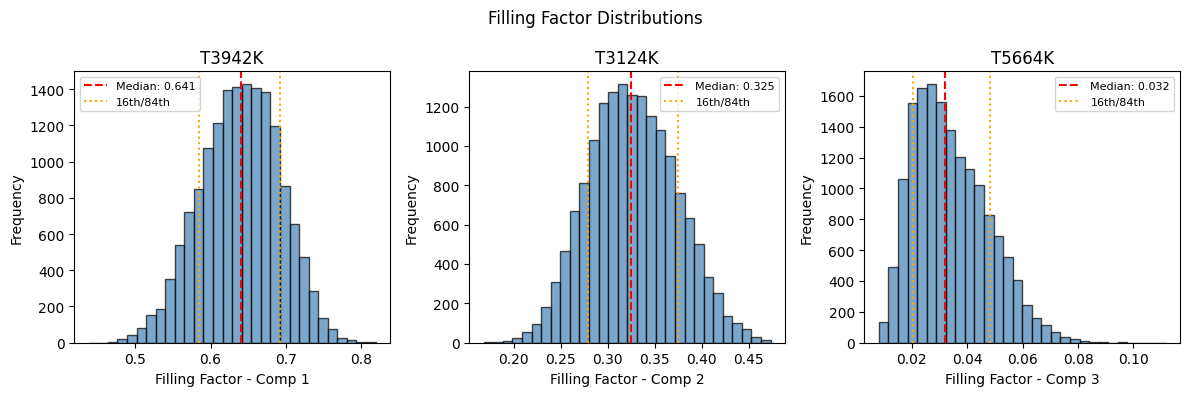

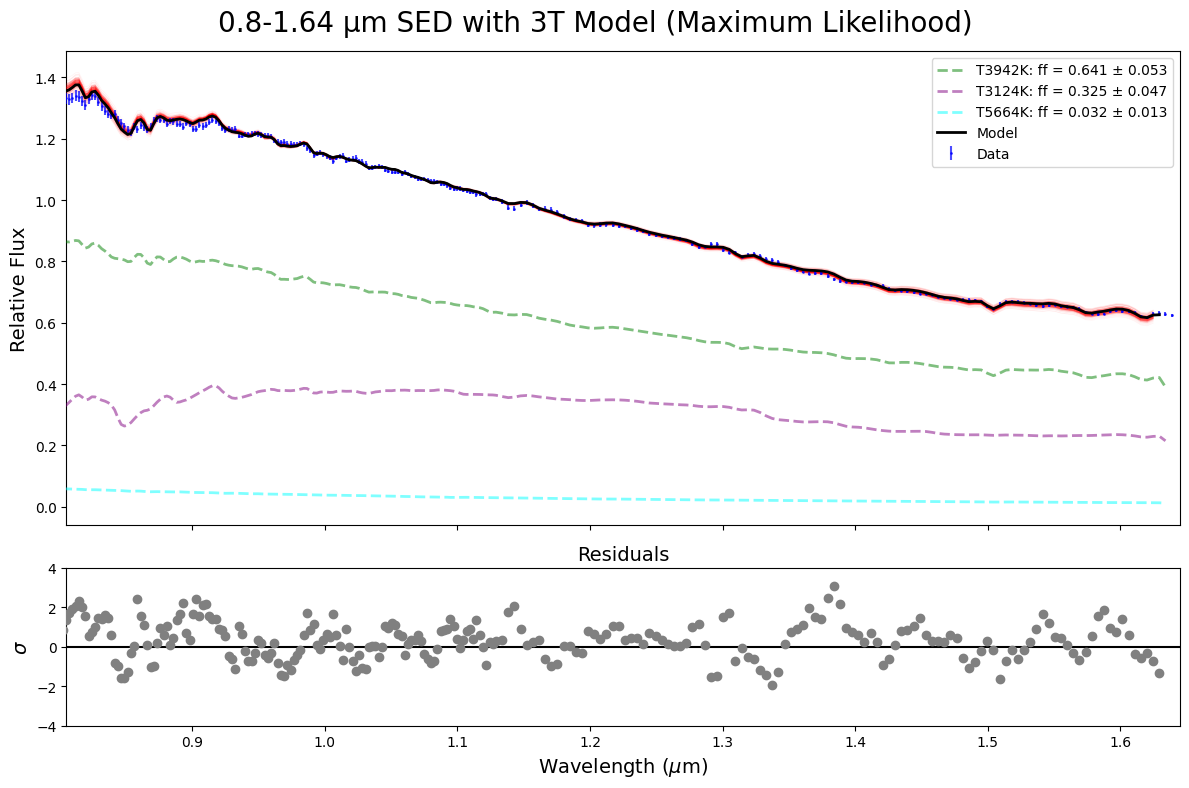

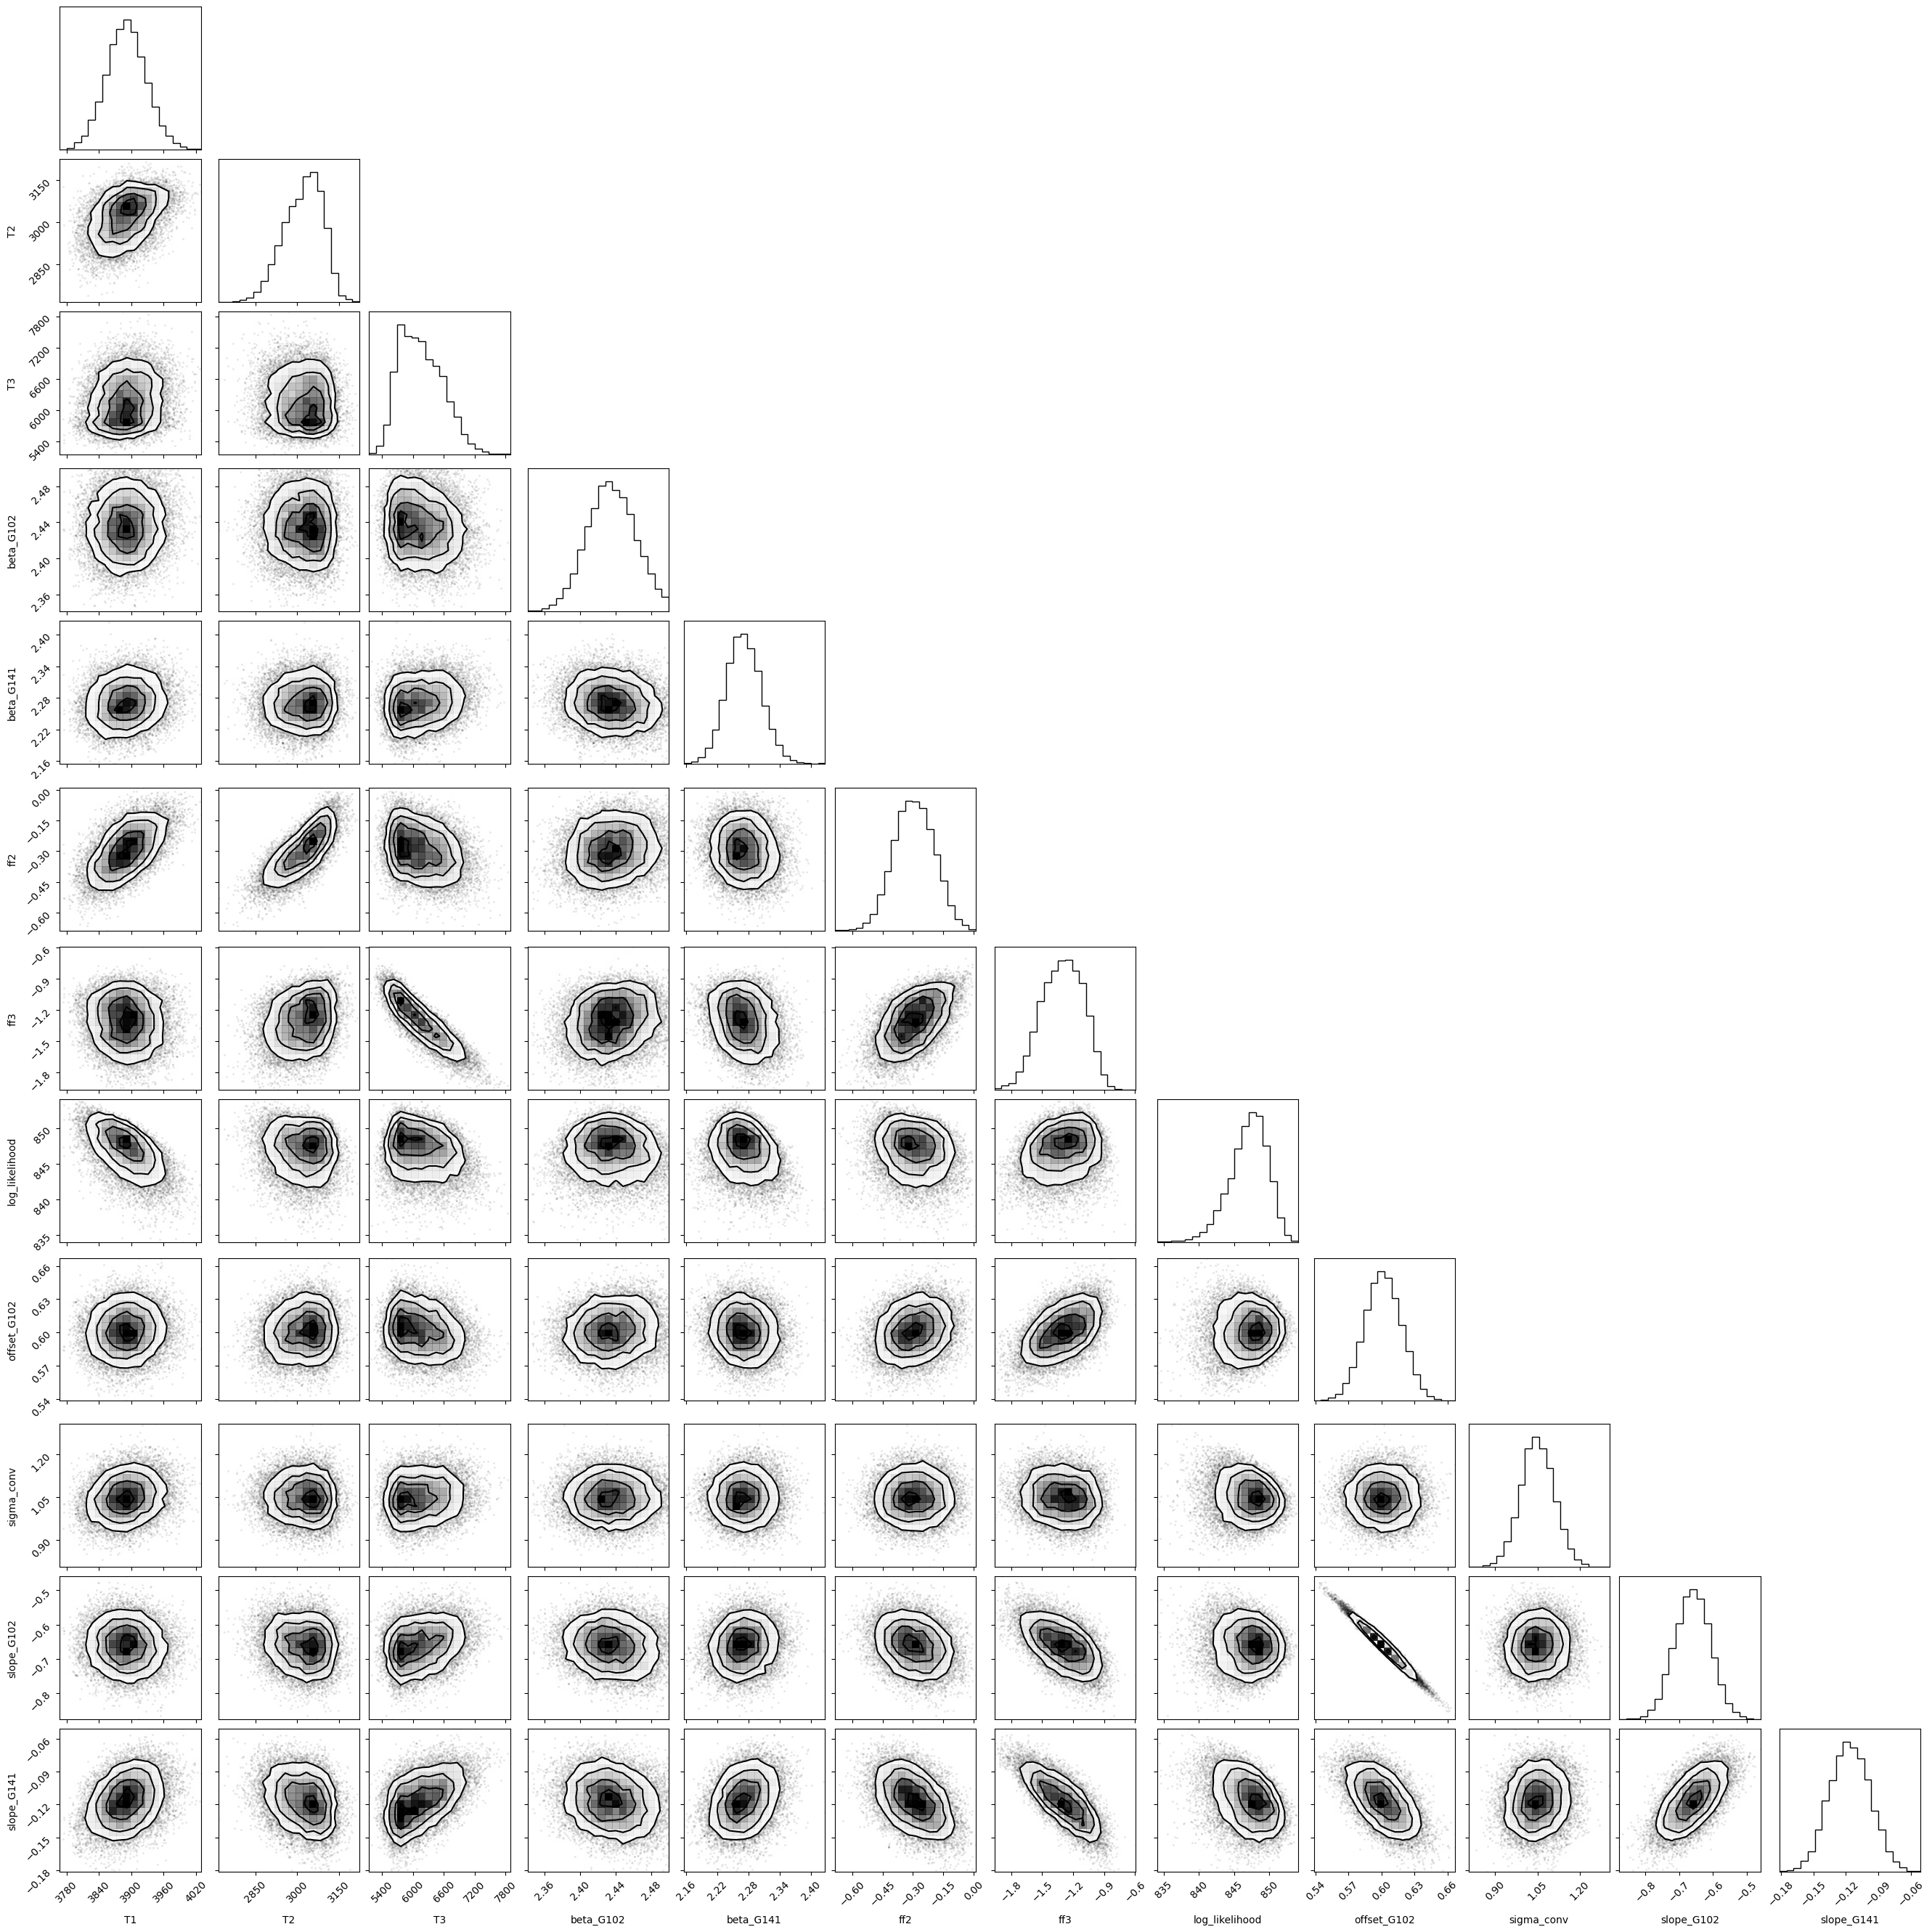

In [15]:
plot_sed_fit_results(mcmc, model_designation, n_temps)

# Compare multiple models of the same dataset

In [16]:
compare_dict = {}

# BT-Settl generic models
# compare_dict['BT_Settl_generic_1T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_1T_2000_8chains_SED_btsettl_generic-logg4.5')
# compare_dict['BT_Settl_generic_2T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_8chains_SED_btsettl_generic-logg4.5')
# compare_dict['BT_Settl_generic_3T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_2000_8chains_SED_btsettl_generic-logg4.5')

# BT-Settl AGSS Models
# compare_dict['BT_Settl_agss_1T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_1T_2000_8chains_SED_btsettl_agss-logg4.5')
# compare_dict['BT_Settl_agss_2T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_8chains_SED_btsettl_agss-logg4.5')
# compare_dict['BT_Settl_agss_3T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_2000_8chains_SED_btsettl_agss-logg4.5')
# compare_dict['BT_Settl_agss_1T_met0'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_1T_2000_8chains_SED_btsettl_agss-logg4.5-met0.0')
compare_dict['BT_Settl_agss_2T_met0'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_8chains_SED_btsettl_agss-logg4.5-met0.0')
compare_dict['BT_Settl_agss_3T_met0'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_2000_8chains_SED_btsettl_agss-logg4.5-met0.0')

# Sphinx Models
# compare_dict['Sphinx1T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_1T_2000_8chains_SED_sphinx_logg4.5')
# compare_dict['Sphinx2T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_8chains_SED_sphinx_logg4.5')
# compare_dict['Sphinx3T'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_2000_8chains_SED_sphinx_logg4.5')
# compare_dict['Sphinx1T_met0'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_1T_2000_8chains_SED_sphinx_logg4.5_met0')
# compare_dict['Sphinx2T_met0'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_8chains_SED_sphinx_logg4.5_met0')
# compare_dict['Sphinx3T_met0'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_2000_8chains_SED_sphinx_logg4.5_met0')

arviz.compare(compare_dict)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
BT_Settl_agss_3T_met0,0,841.994389,9.473416,0.00000,1.0,12.534967,0.000000,False,log
BT_Settl_agss_2T_met0,1,821.608099,7.742721,20.38629,0.0,11.447850,5.848352,False,log


From https://num.pyro.ai/en/latest/tutorials/bad_posterior_geometry.html

In general it is difficult to assess whether the samples returned from HMC or NUTS represent accurate (approximate) samples from the posterior. Two general rules of thumb, however, are to look at the effective sample size (ESS) and r_hat diagnostics returned by mcmc.print_summary(). If we see values of r_hat in the range (1.0, 1.05) and effective sample sizes that are comparable to the total number of samples num_samples (assuming thinning=1) then we have good reason to believe that HMC is doing a good job. If, however, we see low effective sample sizes or large r_hats for some of the variables (e.g. r_hat = 1.15) then HMC is likely struggling with the posterior geometry. In the following we will use r_hat as our primary diagnostic metric.